In [4]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import LabelEncoder
import numpy as np # Basic computation library
import seaborn as sns # For Visualization
import matplotlib.pyplot as plt # ploting package
%matplotlib inline
import warnings # Filtering warnings
warnings.filterwarnings('ignore')

In [5]:
df=pd.read_csv(r'C:\Users\ARPITA\Downloads\Student Depression Dataset (1).csv')

In [6]:
print('No of Rows:',df.shape[0])
print('No of Columns:',df.shape[1])
pd.set_option('display.max_columns', None)
df.head()

No of Rows: 27901
No of Columns: 18


,id,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,2,Male,33.0,Visakhapatnam,Student,5.0,0.0,8.97,2.0,0.0,5-6 hours,Healthy,B.Pharm,Yes,3.0,1.0,No,1
1,8,Female,24.0,Bangalore,Student,2.0,0.0,5.90,5.0,0.0,5-6 hours,Moderate,BSc,No,3.0,2.0,Yes,0
2,26,Male,31.0,Srinagar,Student,3.0,0.0,7.03,5.0,0.0,Less than 5 hours,Healthy,BA,No,9.0,1.0,Yes,0
3,30,Female,28.0,Varanasi,Student,3.0,0.0,5.59,2.0,0.0,7-8 hours,Moderate,BCA,Yes,4.0,5.0,Yes,1
4,32,Female,25.0,Jaipur,Student,4.0,0.0,8.13,3.0,0.0,5-6 hours,Moderate,M.Tech,Yes,1.0,1.0,No,0


In [7]:
df.columns

Index(['id', 'Gender', 'Age', 'City', 'Profession', 'Academic Pressure',
       'Work Pressure', 'CGPA', 'Study Satisfaction', 'Job Satisfaction',
       'Sleep Duration', 'Dietary Habits', 'Degree',
       'Have you ever had suicidal thoughts ?', 'Work/Study Hours',
       'Financial Stress', 'Family History of Mental Illness', 'Depression'],
      dtype='object')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27901 entries, 0 to 27900
Data columns (total 18 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   id                                     27901 non-null  int64  
 1   Gender                                 27901 non-null  object 
 2   Age                                    27901 non-null  float64
 3   City                                   27901 non-null  object 
 4   Profession                             27901 non-null  object 
 5   Academic Pressure                      27901 non-null  float64
 6   Work Pressure                          27901 non-null  float64
 7   CGPA                                   27901 non-null  float64
 8   Study Satisfaction                     27901 non-null  float64
 9   Job Satisfaction                       27901 non-null  float64
 10  Sleep Duration                         27901 non-null  object 
 11  Di

In [9]:
df.fillna(df.min(), inplace=True)  
df.isnull().sum()

id                                       0
Gender                                   0
Age                                      0
City                                     0
Profession                               0
Academic Pressure                        0
Work Pressure                            0
CGPA                                     0
Study Satisfaction                       0
Job Satisfaction                         0
Sleep Duration                           0
Dietary Habits                           0
Degree                                   0
Have you ever had suicidal thoughts ?    0
Work/Study Hours                         0
Financial Stress                         0
Family History of Mental Illness         0
Depression                               0
dtype: int64

In [10]:
# df.columns.to_series().groupby(df.dtypes).groups

In [11]:

df.duplicated().sum()

0

In [12]:
df.describe().T.round(3)

,count,mean,std,min,25%,50%,75%,max
id,27901.0,70442.149,40641.175,2.0,35039.00,70684.00,105818.00,140699.0
Age,27901.0,25.822,4.906,18.0,21.00,25.00,30.00,59.0
Academic Pressure,27901.0,3.141,1.381,0.0,2.00,3.00,4.00,5.0
Work Pressure,27901.0,0.000,0.044,0.0,0.00,0.00,0.00,5.0
CGPA,27901.0,7.656,1.471,0.0,6.29,7.77,8.92,10.0
Study Satisfaction,27901.0,2.944,1.361,0.0,2.00,3.00,4.00,5.0
Job Satisfaction,27901.0,0.001,0.044,0.0,0.00,0.00,0.00,4.0
Work/Study Hours,27901.0,7.157,3.708,0.0,4.00,8.00,10.00,12.0
Financial Stress,27901.0,3.140,1.437,1.0,2.00,3.00,4.00,5.0
Depression,27901.0,0.585,0.493,0.0,0.00,1.00,1.00,1.0


In [13]:
missing_values = df.isnull().sum().sort_values(ascending =False)
percentage_missing_values =(missing_values/len(df))*100
print(pd.concat([missing_values, percentage_missing_values], axis =1, keys =['Missing Values', '% Missing data']))

                                       Missing Values  % Missing data
id                                                  0             0.0
Gender                                              0             0.0
Family History of Mental Illness                    0             0.0
Financial Stress                                    0             0.0
Work/Study Hours                                    0             0.0
Have you ever had suicidal thoughts ?               0             0.0
Degree                                              0             0.0
Dietary Habits                                      0             0.0
Sleep Duration                                      0             0.0
Job Satisfaction                                    0             0.0
Study Satisfaction                                  0             0.0
CGPA                                                0             0.0
Work Pressure                                       0             0.0
Academic Pressure   

<Axes: >

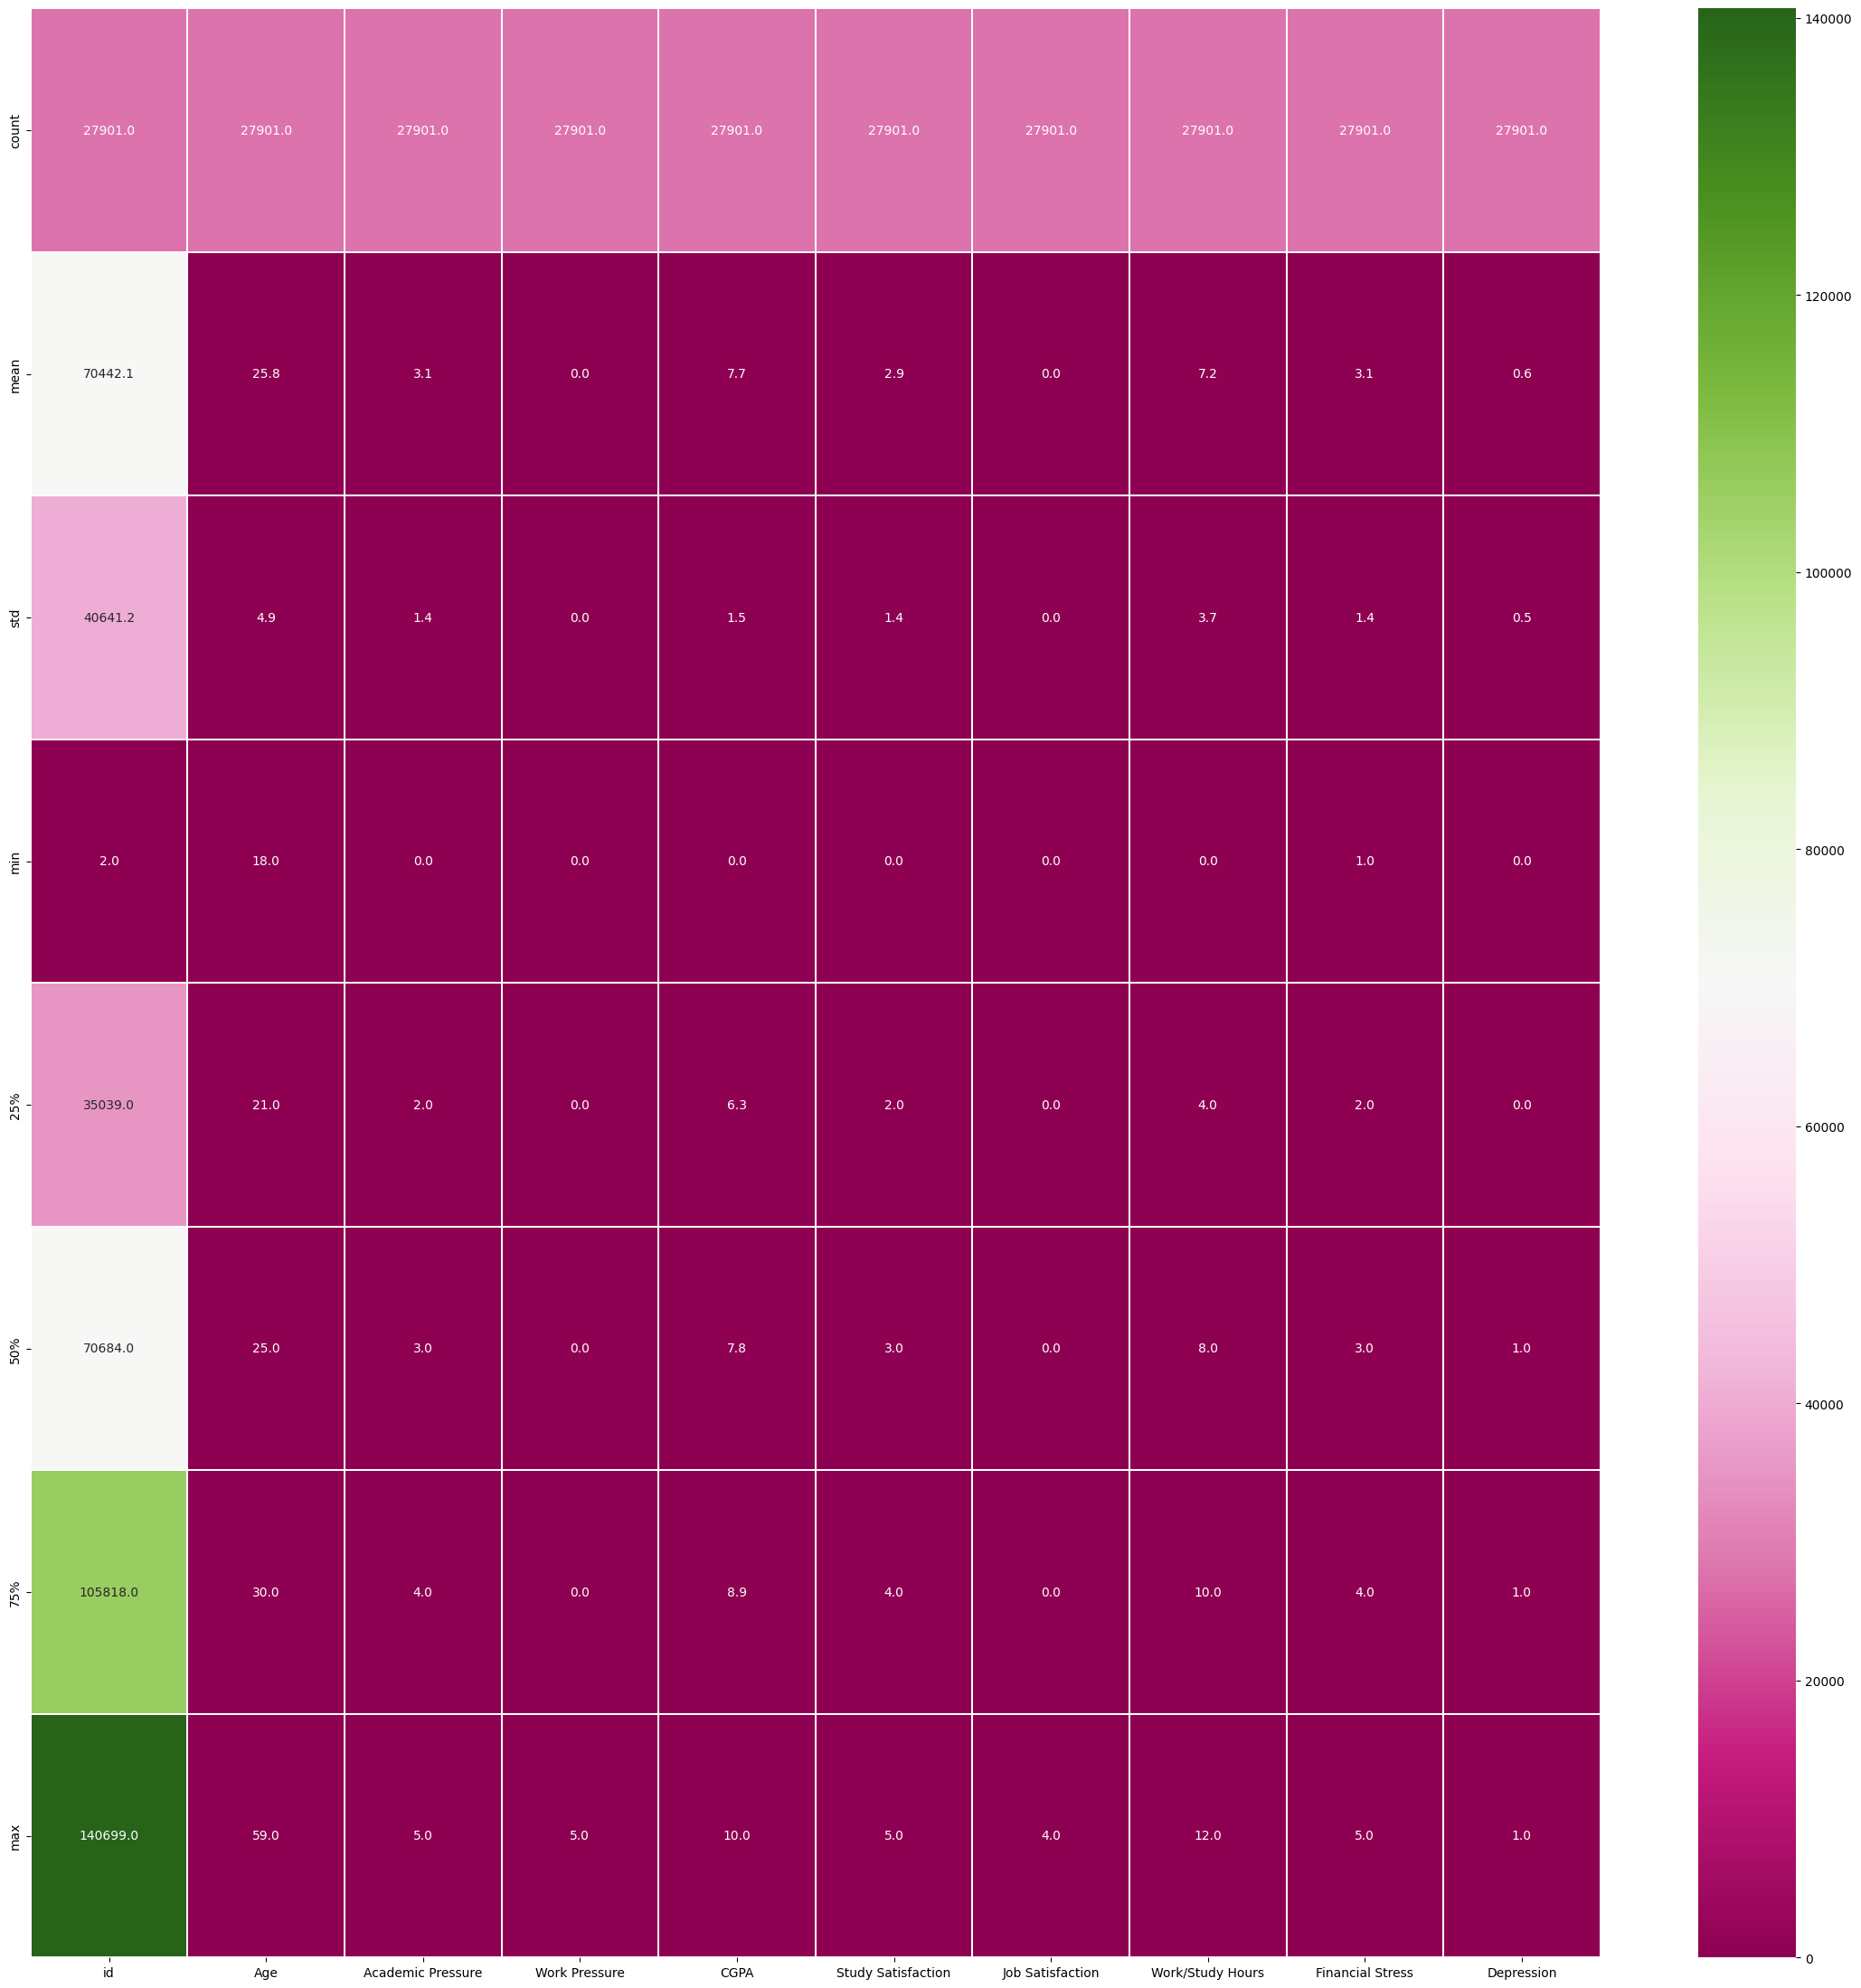

In [14]:
plt.figure(figsize=(28,28))
sns.heatmap(df.describe(),linewidths = 0.1,fmt='0.1f',annot = True,cmap='PiYG')

In [15]:
df['Depression'].value_counts()

Depression
1    16336
0    11565
Name: count, dtype: int64

In [16]:
df.describe().T.round(3)

,count,mean,std,min,25%,50%,75%,max
id,27901.0,70442.149,40641.175,2.0,35039.00,70684.00,105818.00,140699.0
Age,27901.0,25.822,4.906,18.0,21.00,25.00,30.00,59.0
Academic Pressure,27901.0,3.141,1.381,0.0,2.00,3.00,4.00,5.0
Work Pressure,27901.0,0.000,0.044,0.0,0.00,0.00,0.00,5.0
CGPA,27901.0,7.656,1.471,0.0,6.29,7.77,8.92,10.0
Study Satisfaction,27901.0,2.944,1.361,0.0,2.00,3.00,4.00,5.0
Job Satisfaction,27901.0,0.001,0.044,0.0,0.00,0.00,0.00,4.0
Work/Study Hours,27901.0,7.157,3.708,0.0,4.00,8.00,10.00,12.0
Financial Stress,27901.0,3.140,1.437,1.0,2.00,3.00,4.00,5.0
Depression,27901.0,0.585,0.493,0.0,0.00,1.00,1.00,1.0


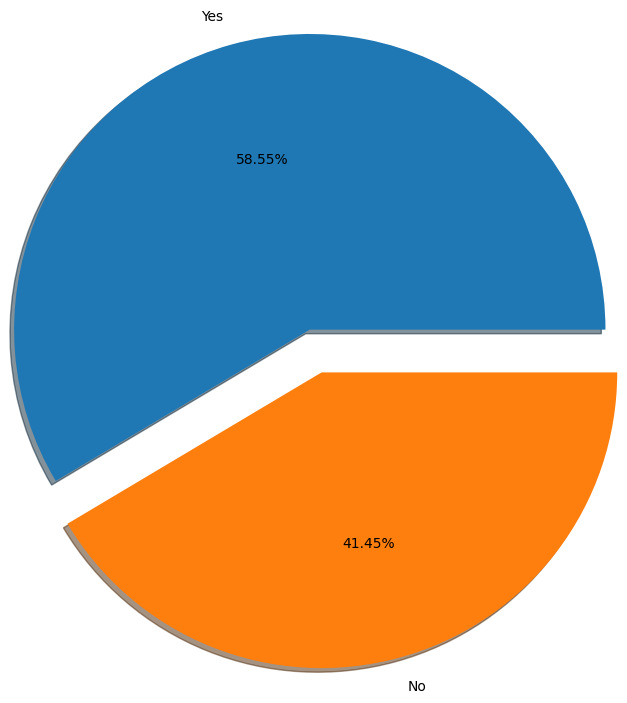

In [17]:
labels = 'Yes','No',
fig, ax = plt.subplots()
ax.pie(df['Depression'].value_counts(),labels = labels,radius =2,autopct = '%2.2f%%',explode=[0.1,0.2], shadow=True,)
plt.show()

In [18]:
Category=['Age', 'Academic Pressure', 'Work Pressure', 'CGPA', 'Study Satisfaction', 'Job Satisfaction', 'Work/Study Hours', 'Financial Stress' ]
for i in Category:
    print(i)
    print(df[i].value_counts())
    print("="*100)

Age
Age
24.0    2258
20.0    2237
28.0    2133
29.0    1950
33.0    1893
25.0    1784
21.0    1726
23.0    1645
18.0    1587
19.0    1560
34.0    1468
27.0    1462
31.0    1427
32.0    1262
22.0    1160
26.0    1155
30.0    1145
35.0      10
38.0       8
36.0       7
42.0       4
48.0       3
39.0       3
43.0       2
46.0       2
37.0       2
49.0       1
51.0       1
44.0       1
59.0       1
54.0       1
58.0       1
56.0       1
41.0       1
Name: count, dtype: int64
Academic Pressure
Academic Pressure
3.0    7462
5.0    6296
4.0    5155
1.0    4801
2.0    4178
0.0       9
Name: count, dtype: int64
Work Pressure
Work Pressure
0.0    27898
5.0        2
2.0        1
Name: count, dtype: int64
CGPA
CGPA
8.04    821
9.96    425
5.74    410
8.95    371
9.21    343
       ... 
7.65      1
6.77      1
8.26      1
7.23      1
6.09      1
Name: count, Length: 332, dtype: int64
Study Satisfaction
Study Satisfaction
4.0    6359
2.0    5838
3.0    5821
1.0    5451
5.0    4422
0.0      10
Name: 

In [19]:
df.isnull().sum()

id                                       0
Gender                                   0
Age                                      0
City                                     0
Profession                               0
Academic Pressure                        0
Work Pressure                            0
CGPA                                     0
Study Satisfaction                       0
Job Satisfaction                         0
Sleep Duration                           0
Dietary Habits                           0
Degree                                   0
Have you ever had suicidal thoughts ?    0
Work/Study Hours                         0
Financial Stress                         0
Family History of Mental Illness         0
Depression                               0
dtype: int64

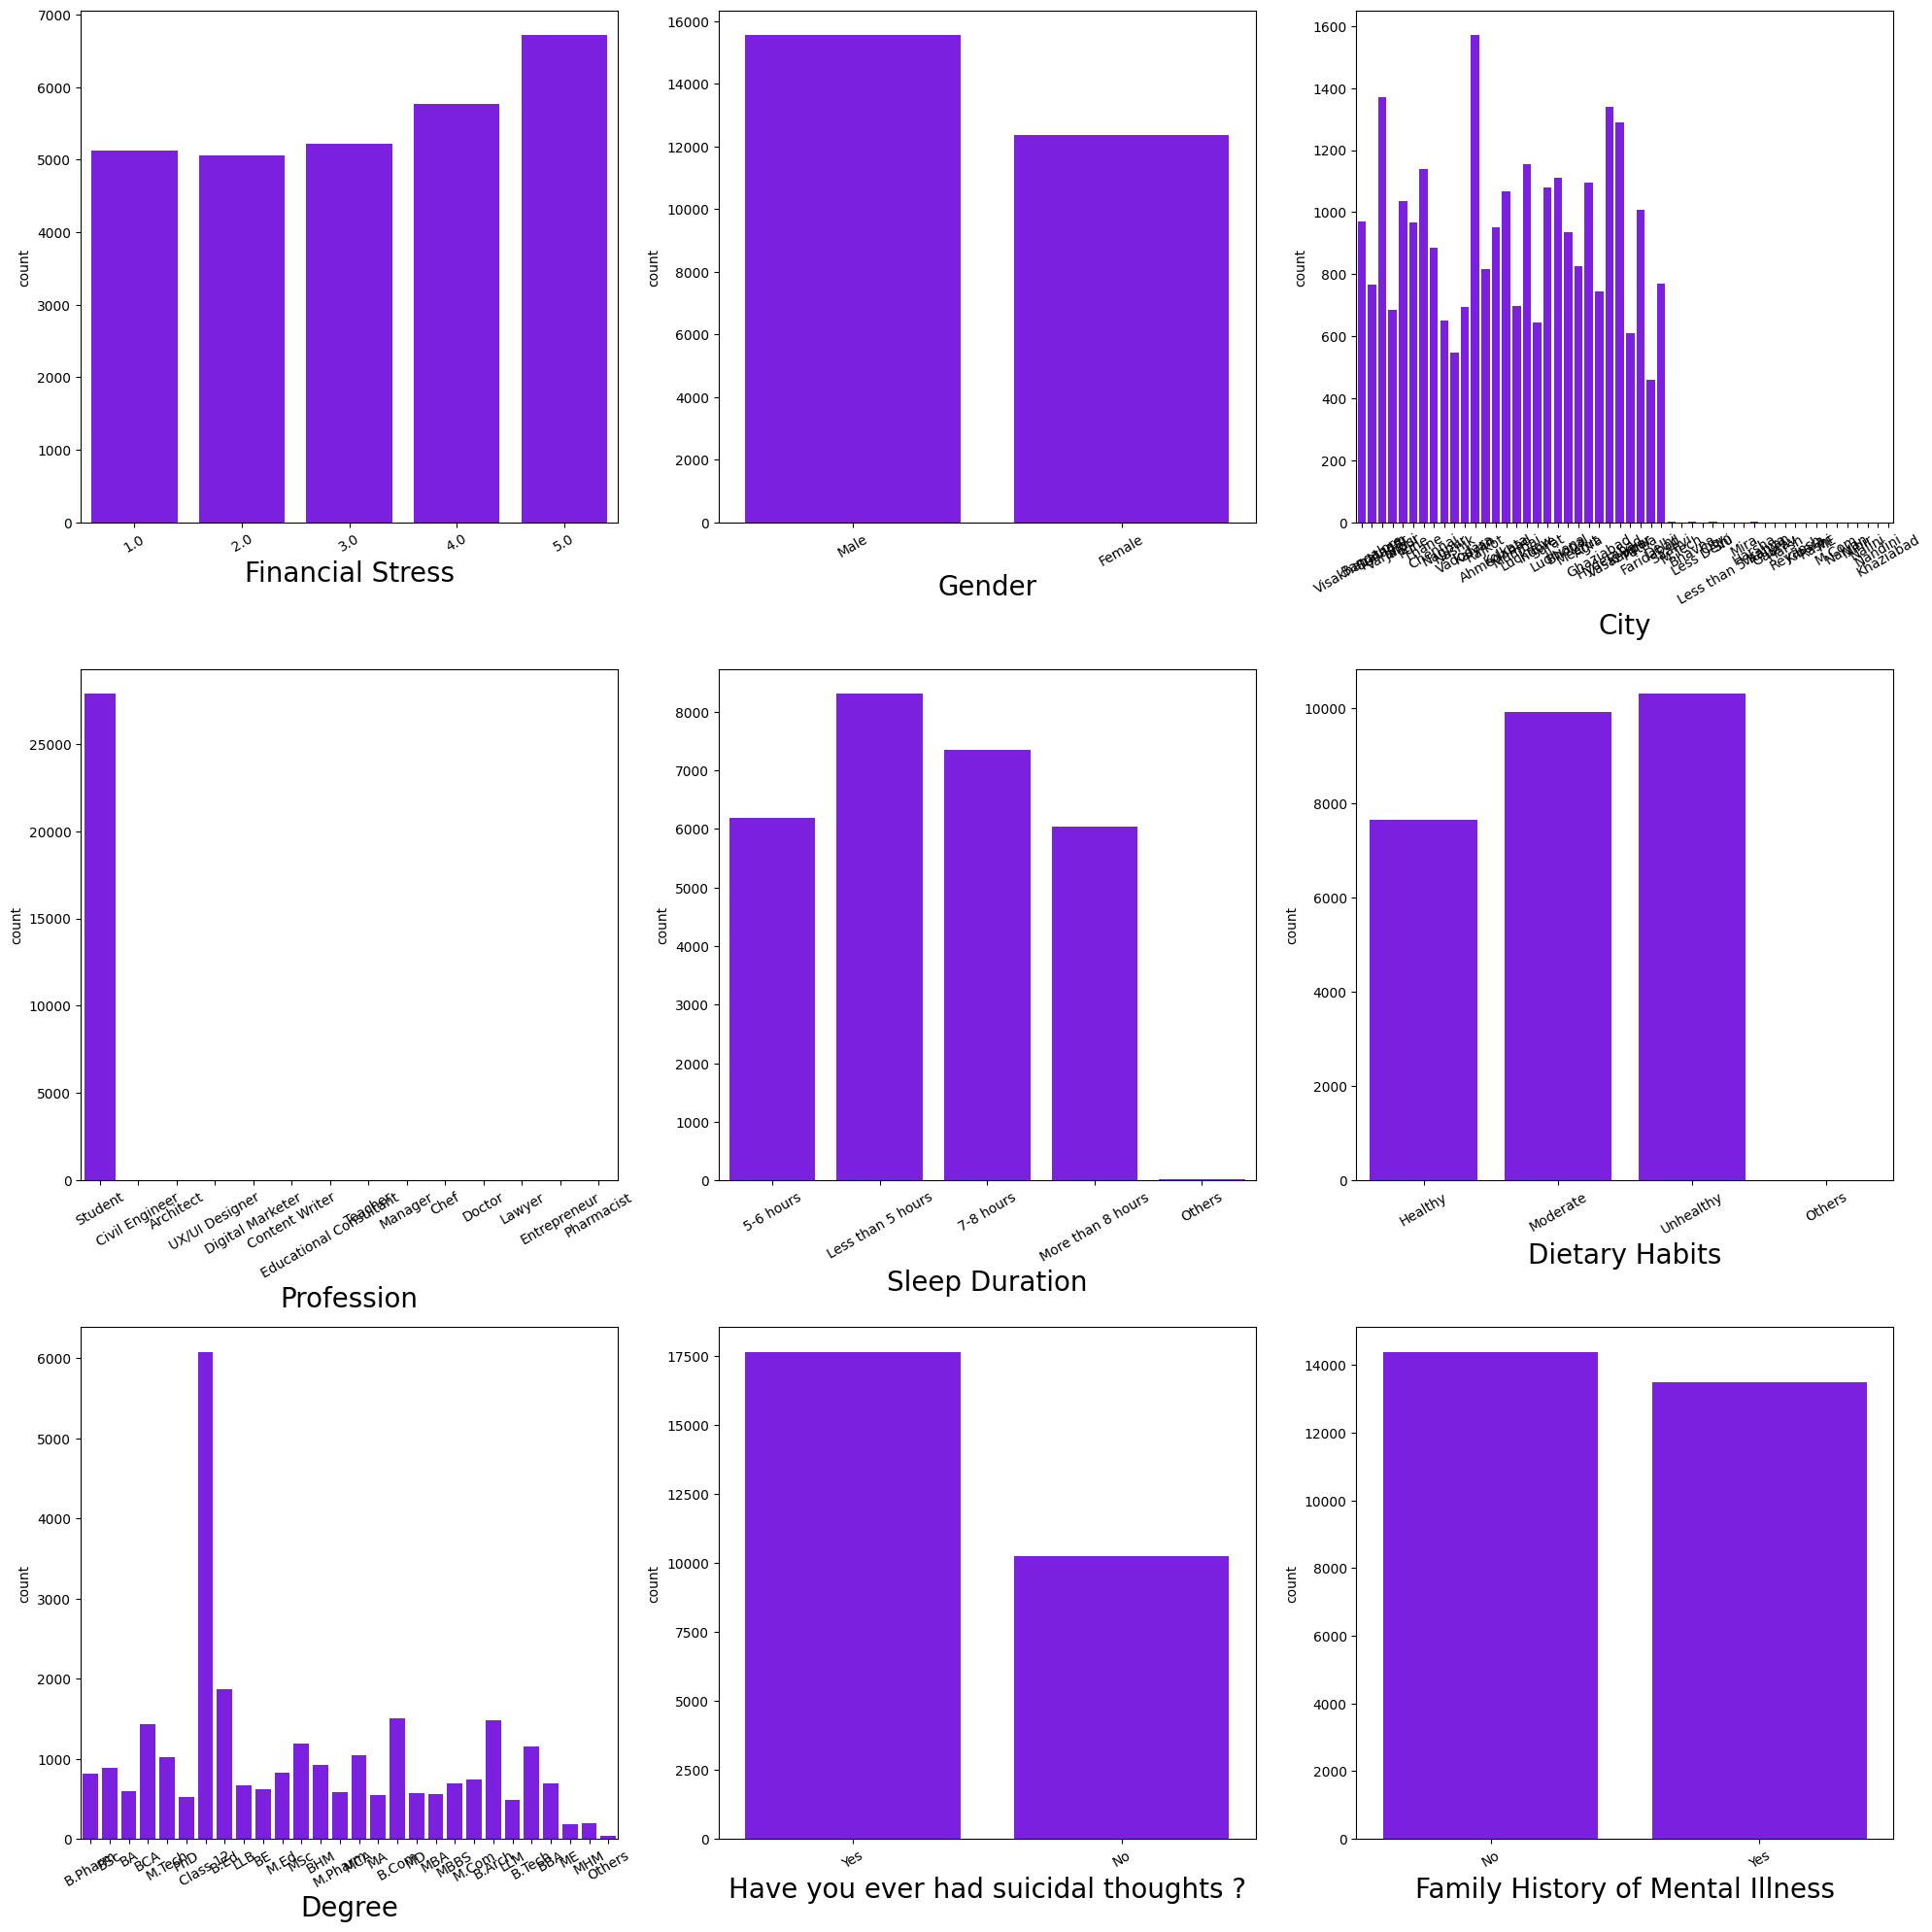

In [20]:
sns.set_palette('gist_rainbow_r')
plt.figure(figsize=(20,20), facecolor='white')
plotnumber =1
Category=['Financial Stress','Gender', 'City', 'Profession', 'Sleep Duration', 'Dietary Habits', 'Degree', 'Have you ever had suicidal thoughts ?', 'Family History of Mental Illness' ]
for i in Category:
    if plotnumber <=9:
        ax = plt.subplot(3,3,plotnumber)
        sns.countplot(x = df[i])
        plt.xlabel(i,fontsize=20)
        plt.xticks(rotation=30)
    plotnumber+=1
plt.tight_layout()
plt.show()

In [21]:
Ordinal=['Gender', 'City', 'Profession', 'Sleep Duration', 'Dietary Habits', 'Degree', 'Have you ever had suicidal thoughts ?', 'Family History of Mental Illness' ]
for i in Ordinal:
    print(i)
    print(df[i].value_counts())
    print("="*100)

Gender
Gender
Male      15547
Female    12354
Name: count, dtype: int64
City
City
Kalyan                1570
Srinagar              1372
Hyderabad             1340
Vasai-Virar           1290
Lucknow               1155
Thane                 1139
Ludhiana              1111
Agra                  1094
Surat                 1078
Kolkata               1066
Jaipur                1036
Patna                 1007
Visakhapatnam          969
Pune                   968
Ahmedabad              951
Bhopal                 934
Chennai                885
Meerut                 825
Rajkot                 816
Delhi                  768
Bangalore              767
Ghaziabad              745
Mumbai                 699
Vadodara               694
Varanasi               685
Nagpur                 651
Indore                 643
Kanpur                 609
Nashik                 547
Faridabad              461
Saanvi                   2
Bhavna                   2
City                     2
Harsha                   2


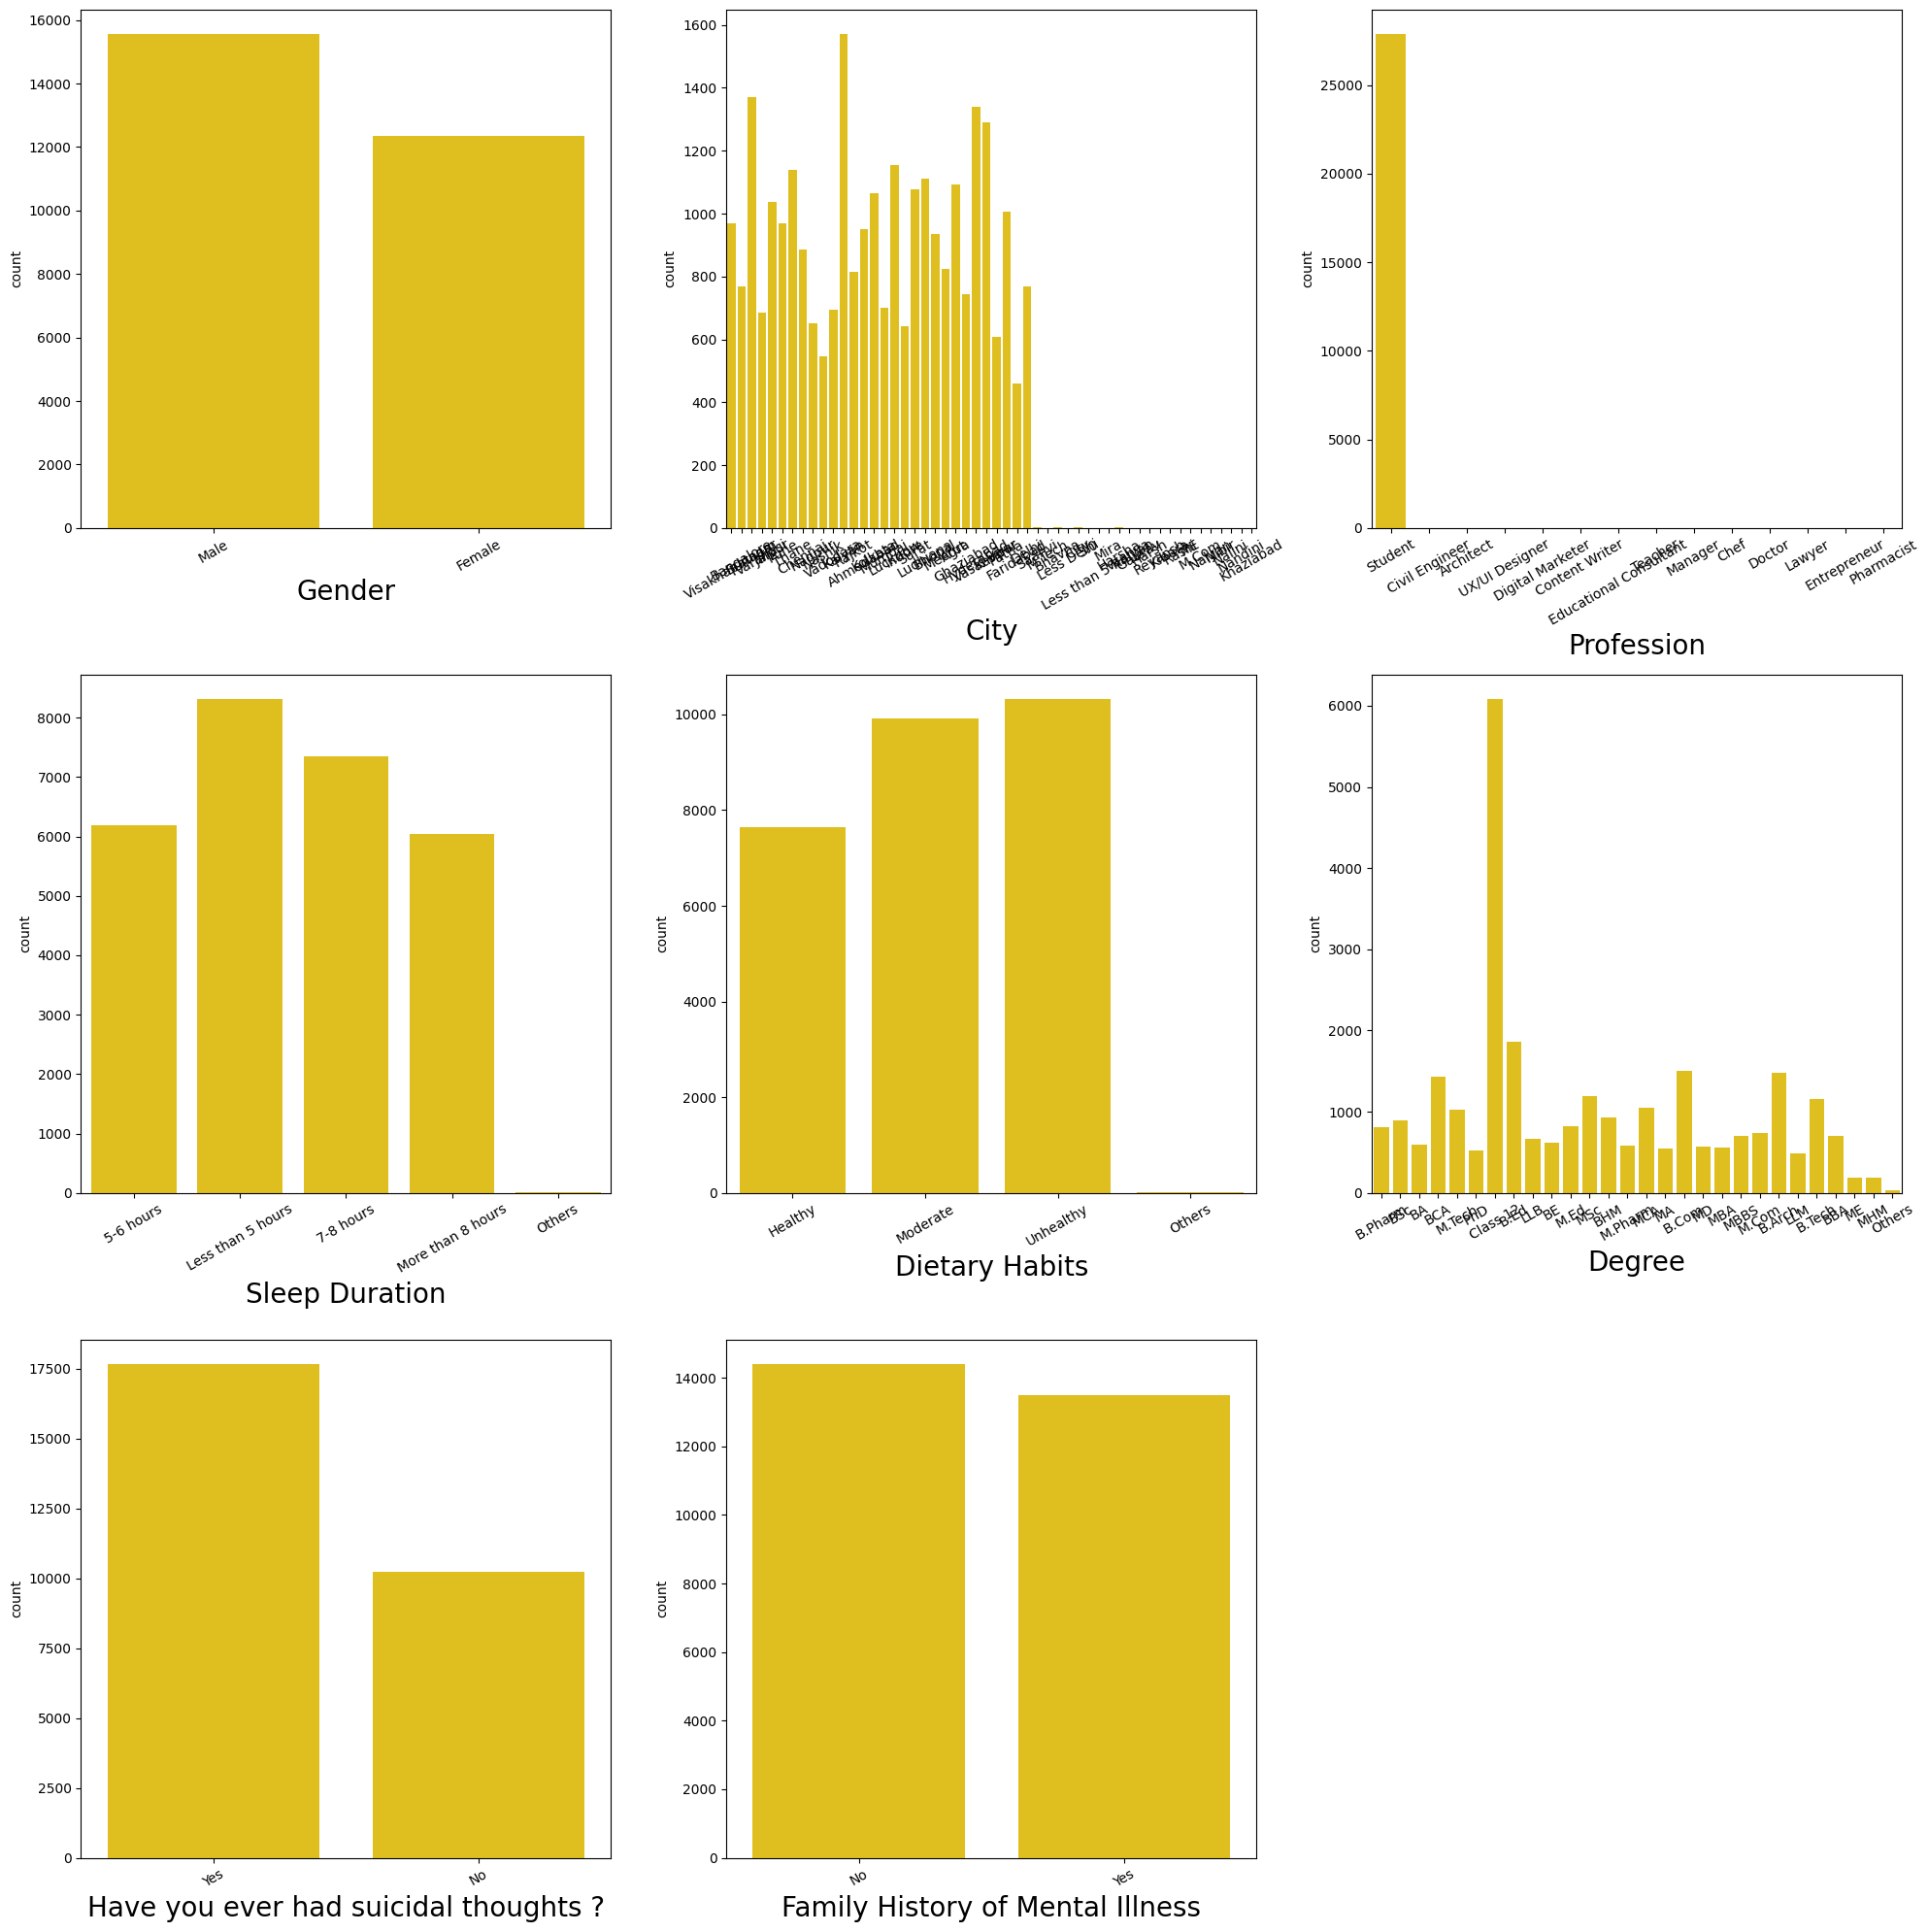

In [22]:
sns.set_palette('hsv')
plt.figure(figsize=(20,20), facecolor='white')
plotnumber =1
Ordinal=['Gender', 'City', 'Profession', 'Sleep Duration', 'Dietary Habits', 'Degree', 'Have you ever had suicidal thoughts ?', 'Family History of Mental Illness' ]
for i in Ordinal:
    if plotnumber <=9:
        ax = plt.subplot(3,3,plotnumber)
        sns.countplot(x = df[i])
        plt.xlabel(i,fontsize=20)
        plt.xticks(rotation=30)
    plotnumber+=1
plt.tight_layout()
plt.show()

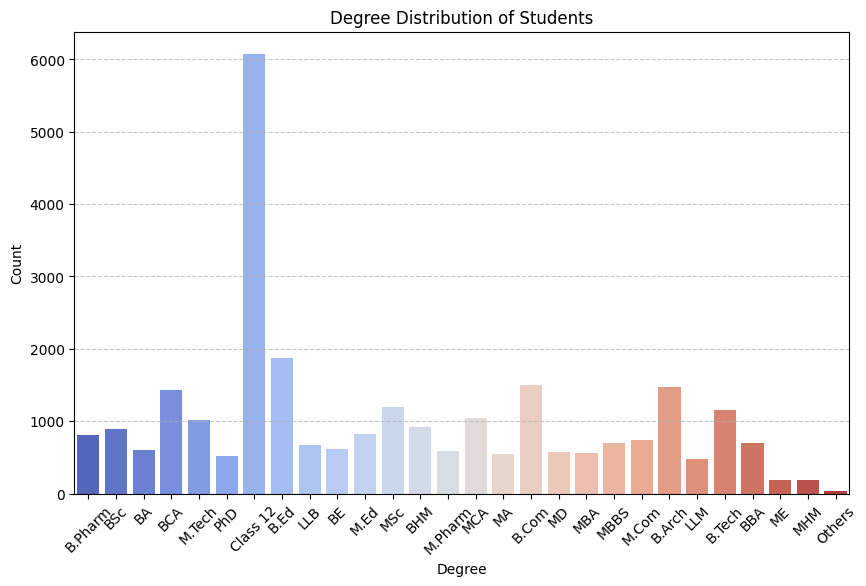

In [23]:
plt.figure(figsize=(10, 6))
sns.countplot(x=df["Degree"], palette="coolwarm")

plt.title("Degree Distribution of Students")
plt.xlabel("Degree")
plt.ylabel("Count")
plt.xticks(rotation=45)  # Rotate labels if needed
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

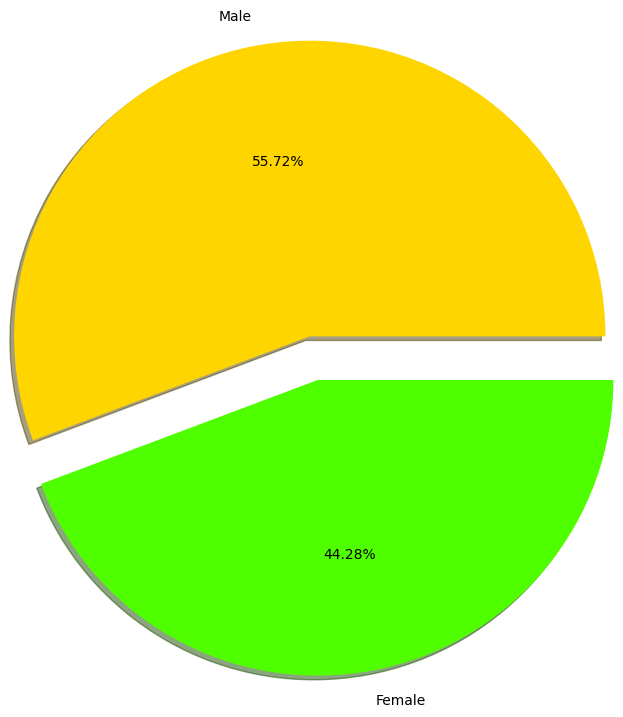

In [24]:
labels='Male','Female'
fig, ax = plt.subplots()
ax.pie(df['Gender'].value_counts(),labels = labels,radius =2,autopct = '%3.2f%%',explode=[0.1,0.2], shadow=True,)
plt.show()

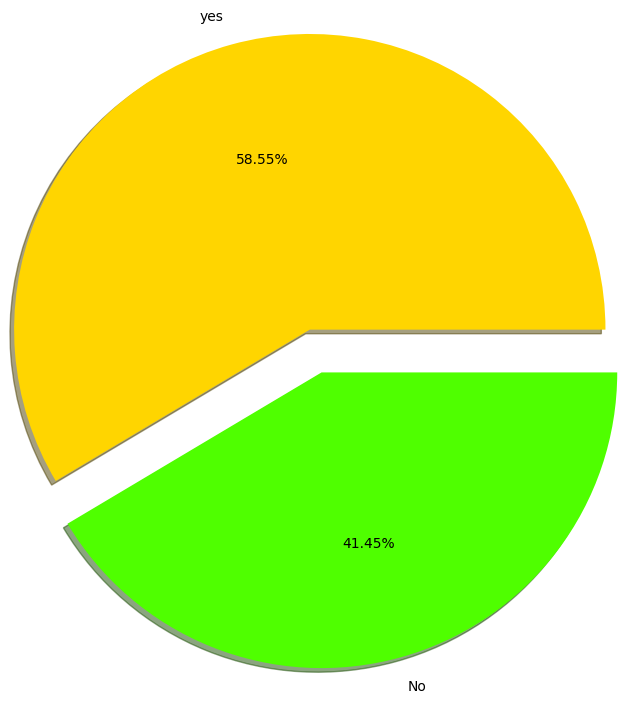

In [25]:
labels='yes','No'
fig, ax = plt.subplots()
ax.pie(df['Depression'].value_counts(),labels = labels,radius =2,autopct = '%3.2f%%',explode=[0.1,0.2], shadow=True,)
plt.show()

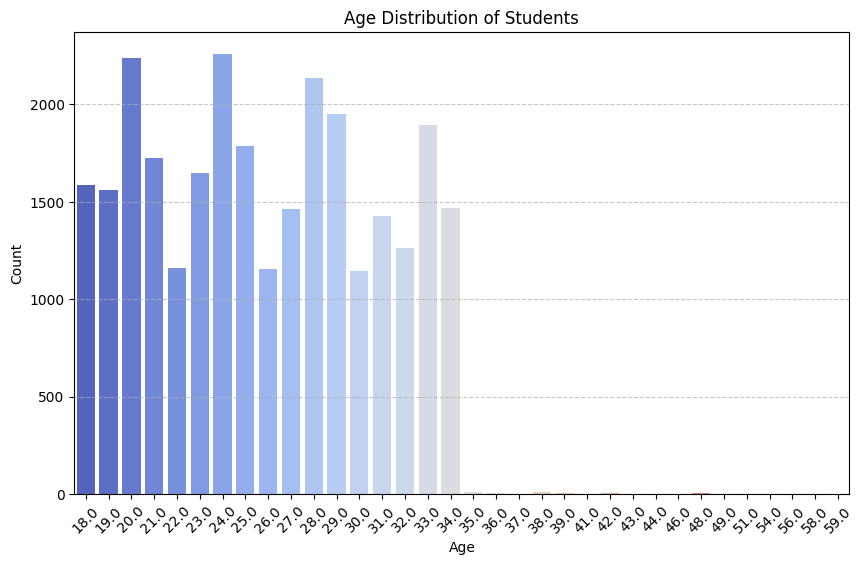

In [26]:
plt.figure(figsize=(10, 6))
sns.countplot(x=df["Age"], palette="coolwarm")

plt.title("Age Distribution of Students")
plt.xlabel("Age")
plt.ylabel("Count")
plt.xticks(rotation=45)  # Rotate labels if needed
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

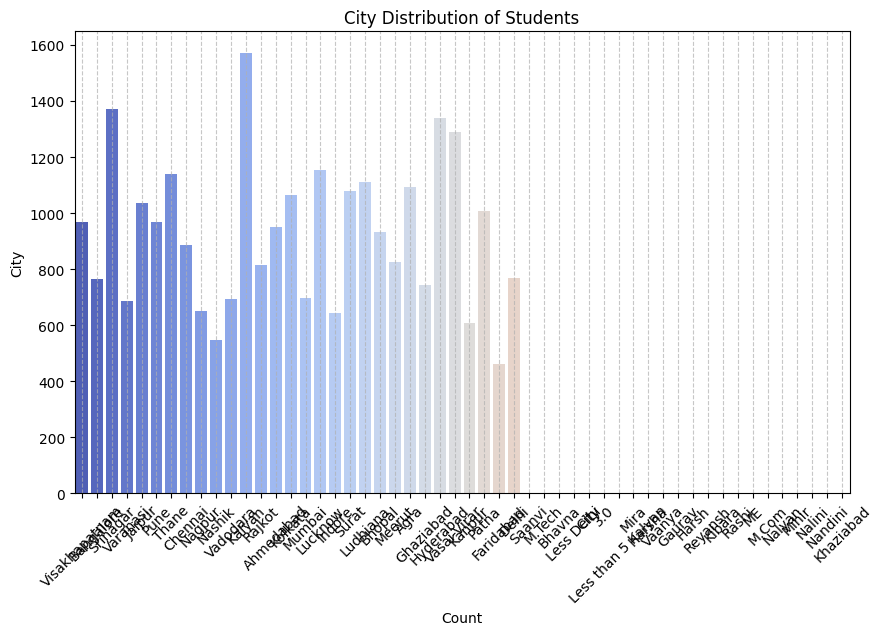

In [27]:
plt.figure(figsize=(10, 6))
sns.countplot(x=df["City"], palette="coolwarm")

plt.title("City Distribution of Students")
plt.xlabel("Count")
plt.ylabel("City")
plt.xticks(rotation=45)  # Rotate labels if needed
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.show()

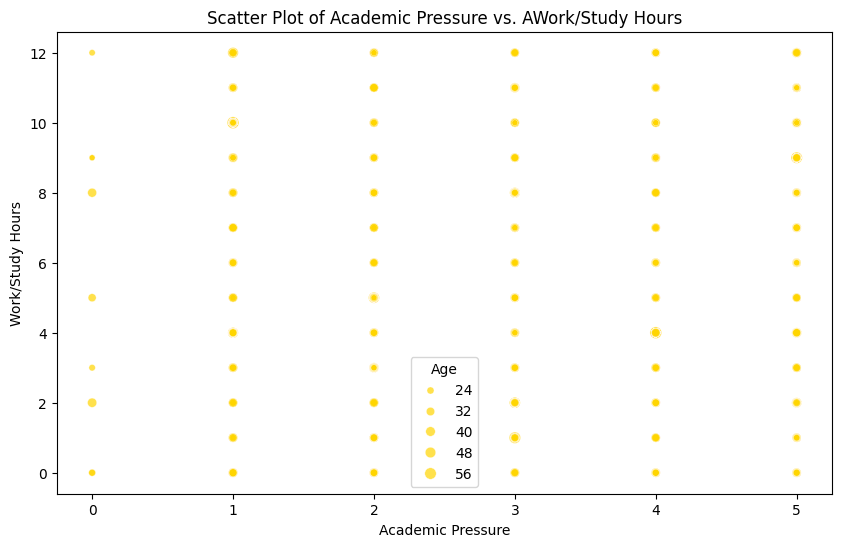

In [28]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=df["Academic Pressure"], y=df["Work/Study Hours"], alpha=0.7, size=df['Age'])

# Label the axes
plt.xlabel("Academic Pressure")
plt.ylabel("Work/Study Hours")
plt.title("Scatter Plot of Academic Pressure vs. AWork/Study Hours")

# Show plot
plt.show()

<Figure size 1200x1000 with 0 Axes>

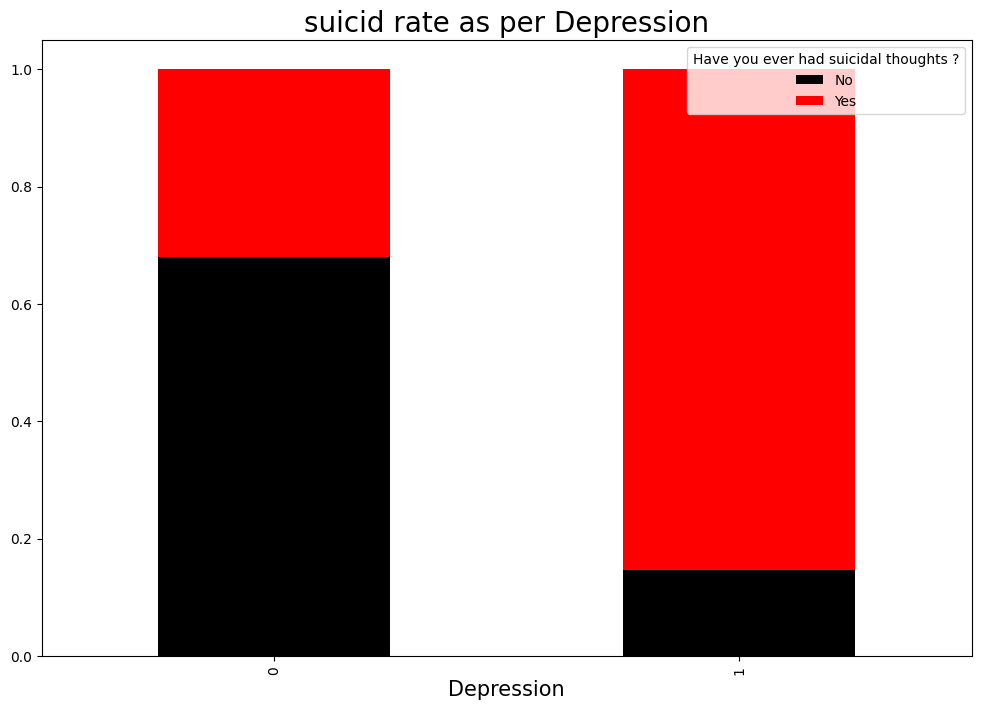

In [29]:
plt.figure(figsize=(12,10))
data=pd.crosstab(df['Depression'], df['Have you ever had suicidal thoughts ?'])
data.div(data.sum(1).astype(float), axis=0).plot(kind='bar', stacked=True,
                    color=['black', 'red'],figsize=(12,8))
plt.title('suicid rate as per Depression', fontsize=20)
plt.xlabel('Depression',fontsize=15)
plt.show()

In [30]:
pd.crosstab([df.Age],[df.Depression], margins=True).style.background_gradient(cmap='summer_r')

Depression,0,1,All
Age,,,
18.000000,371,1216,1587
19.000000,460,1100,1560
20.000000,658,1579,2237
21.000000,557,1169,1726
22.000000,459,701,1160
23.000000,594,1051,1645
24.000000,749,1509,2258
25.000000,702,1082,1784
26.000000,492,663,1155


In [31]:
pd.crosstab(df['Have you ever had suicidal thoughts ?'],[df.Depression], margins=True).style.background_gradient(cmap='summer_r')

Depression,0,1,All
Have you ever had suicidal thoughts ?,,,
No,7866,2379,10245
Yes,3699,13957,17656
All,11565,16336,27901


<Figure size 1200x1000 with 0 Axes>

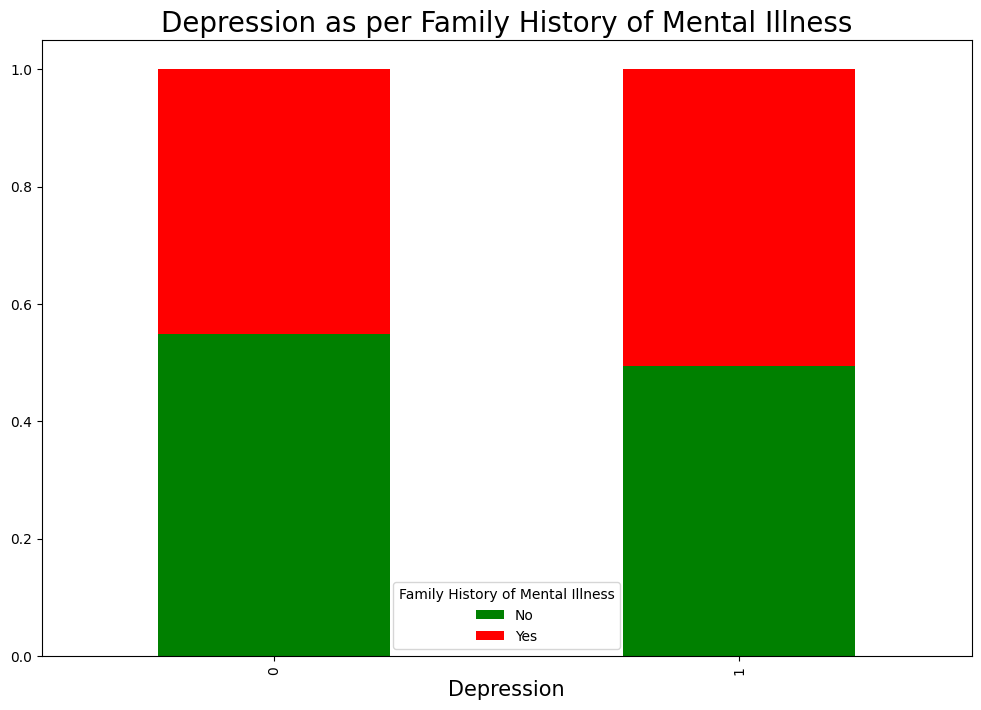

In [32]:
plt.figure(figsize=(12,10))
data=pd.crosstab(df['Depression'], df['Family History of Mental Illness'])
data.div(data.sum(1).astype(float), axis=0).plot(kind='bar', stacked=True,
                    color=['green', 'red'],figsize=(12,8))
plt.title('Depression as per Family History of Mental Illness', fontsize=20)
plt.xlabel('Depression',fontsize=15)
plt.show()

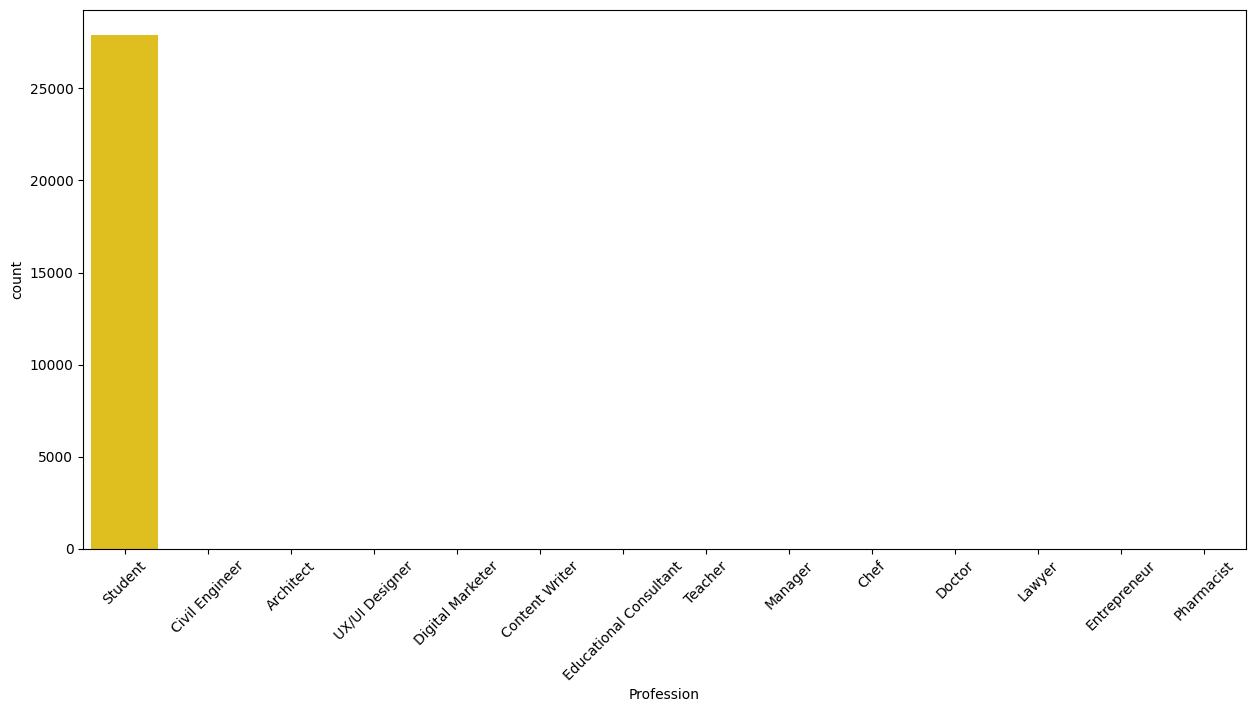

In [33]:
plt.figure(figsize=(15,7))
sns.countplot(x = df['Profession'])
plt.xticks(rotation=45)
plt.show()

In [34]:
num = df.columns
num

Index(['id', 'Gender', 'Age', 'City', 'Profession', 'Academic Pressure',
       'Work Pressure', 'CGPA', 'Study Satisfaction', 'Job Satisfaction',
       'Sleep Duration', 'Dietary Habits', 'Degree',
       'Have you ever had suicidal thoughts ?', 'Work/Study Hours',
       'Financial Stress', 'Family History of Mental Illness', 'Depression'],
      dtype='object')

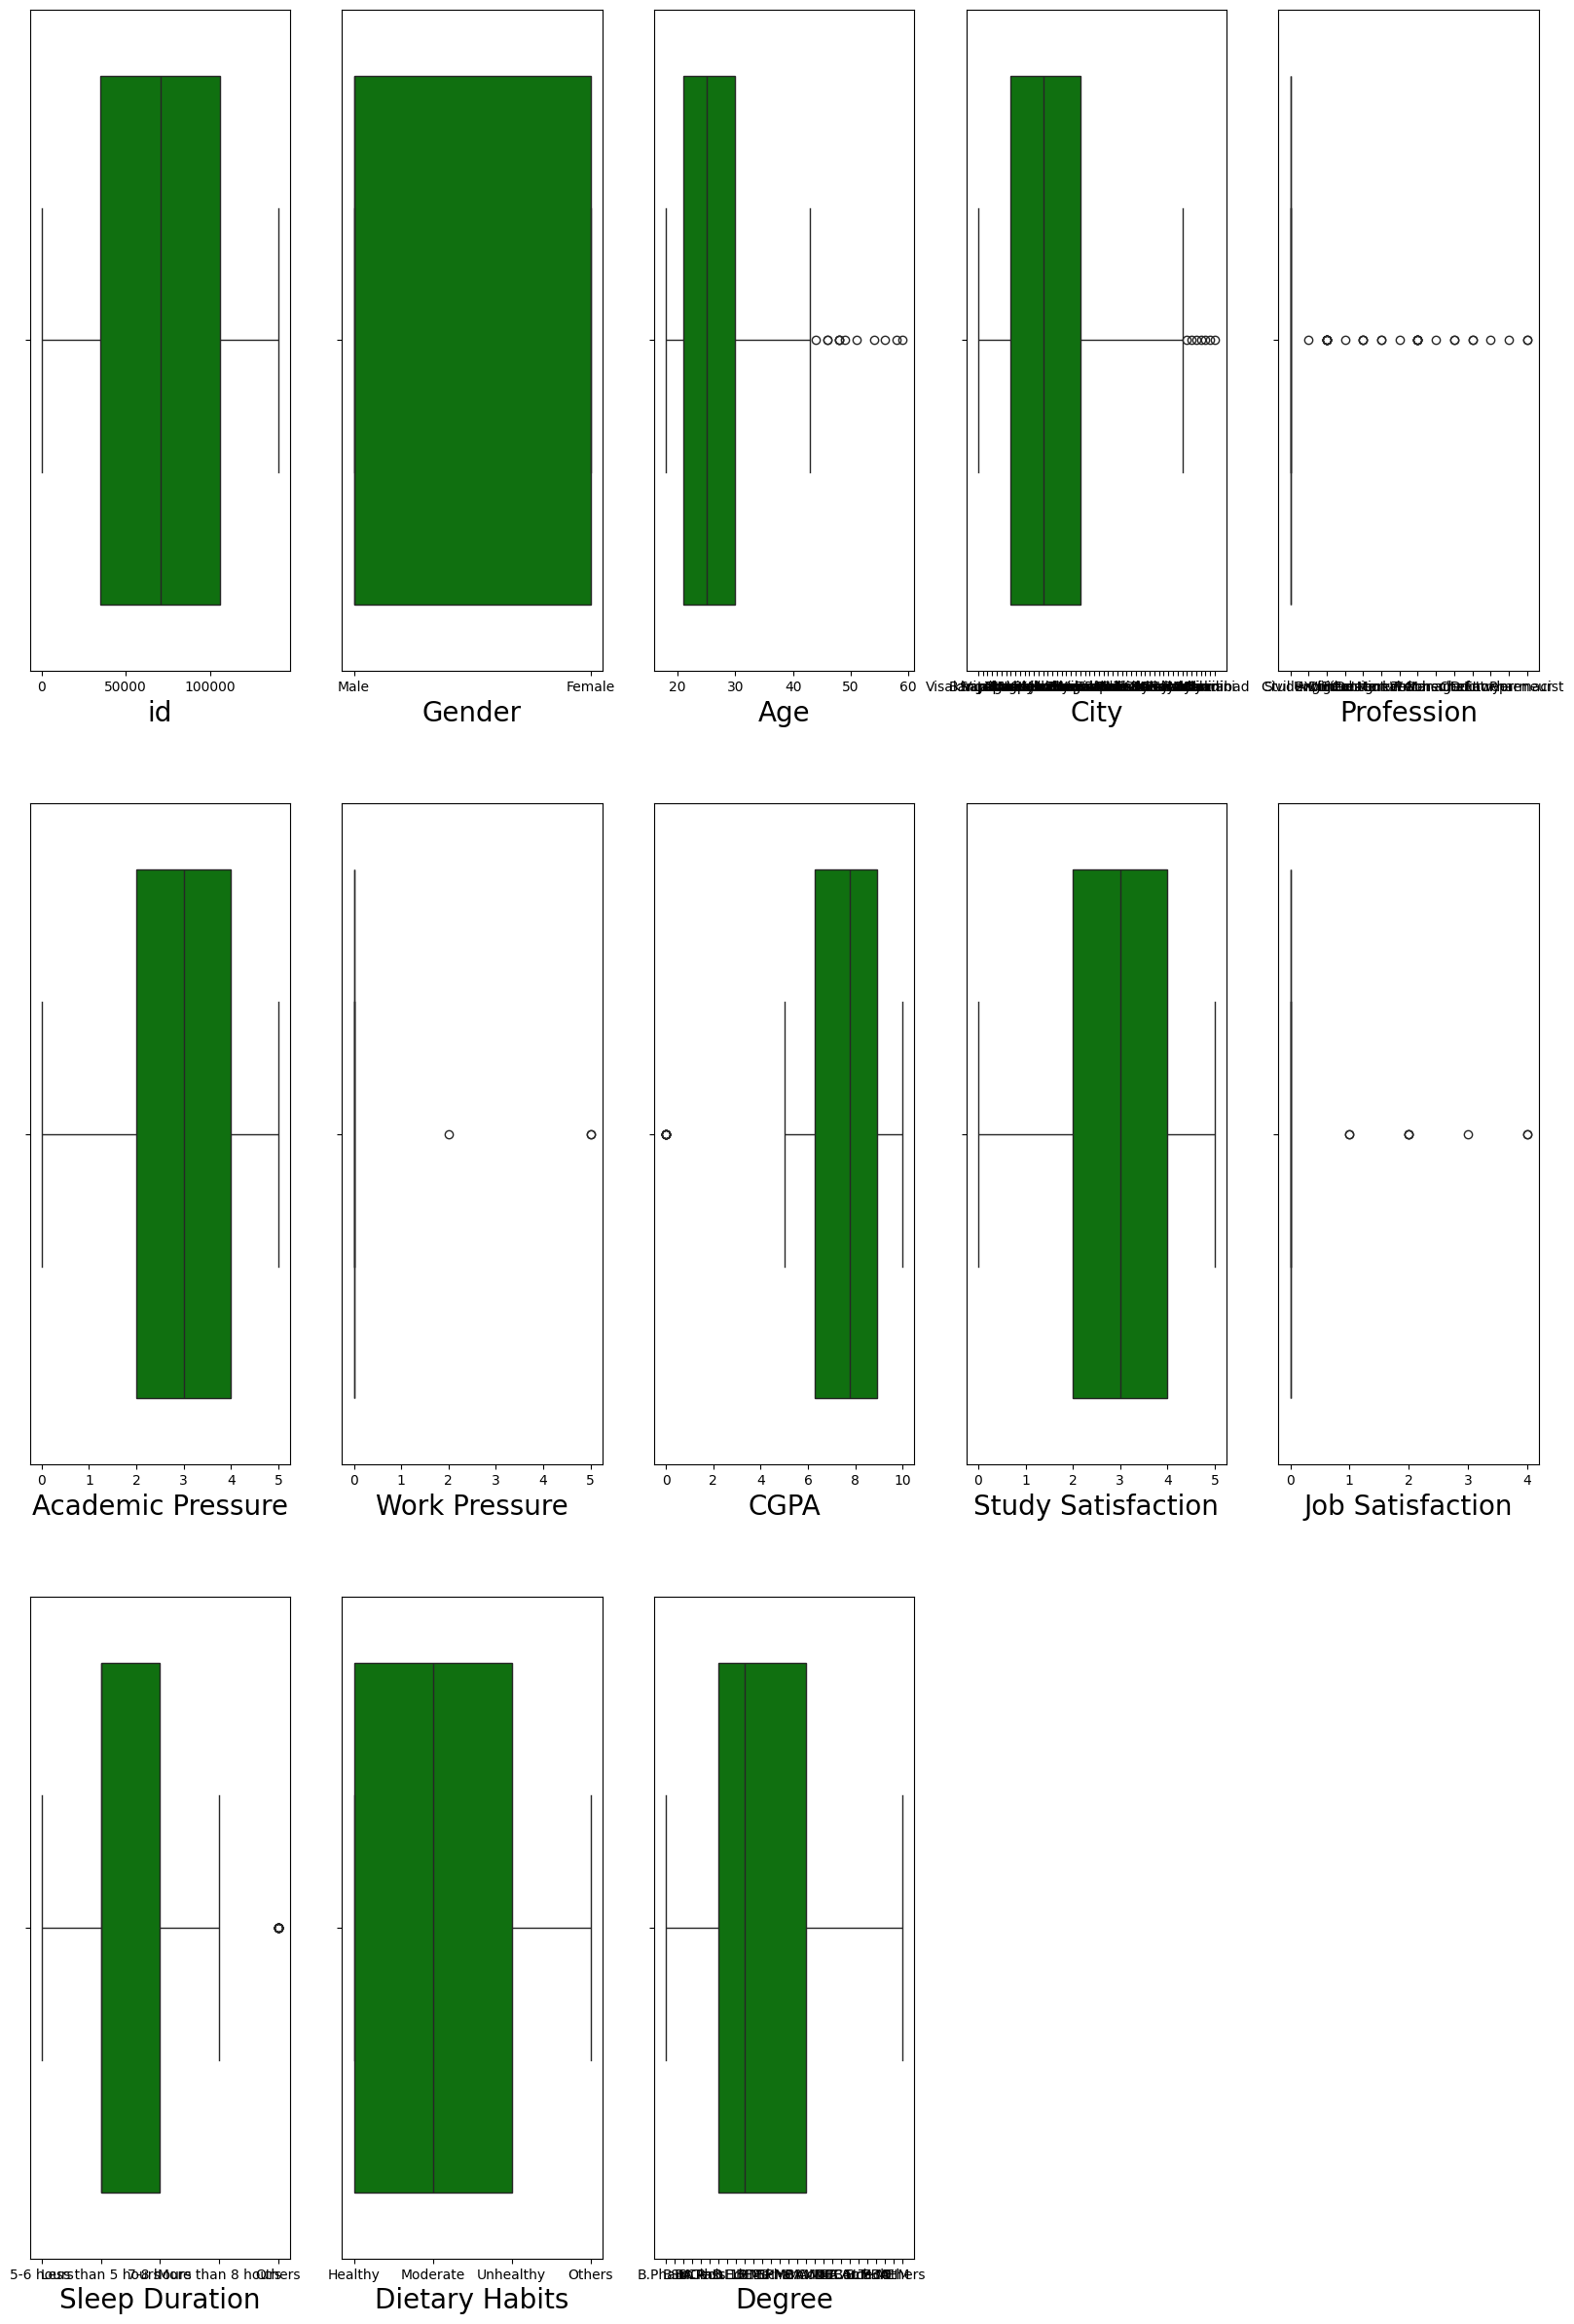

In [35]:
plt.figure(figsize=(20,30),facecolor='white')
plotnumber=1

for column in num:
    if plotnumber<=13:
        ax=plt.subplot(3,5,plotnumber)
        sns.boxplot(x = df[column],color='g')
        plt.xlabel(column,fontsize=20)
    plotnumber+=1
plt.show()

In [36]:
import pandas as pd

# Load dataset
# Select only numeric columns
numeric_cols = df.select_dtypes(include=['number'])

# Compute Q1 and Q3
Q1 = numeric_cols.quantile(0.25)
Q3 = numeric_cols.quantile(0.45)
IQR = Q3 - Q1

# Define bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter out outliers in numeric columns only
df_no_outliers = df[~((numeric_cols < lower_bound) | (numeric_cols > upper_bound)).any(axis=1)]

print(f"Original dataset size: {df.shape[0]}")
print(f"Dataset size after IQR outlier removal: {df_no_outliers.shape[0]}")


Original dataset size: 27901
Dataset size after IQR outlier removal: 6312


In [37]:
# Define a threshold for rare categories (e.g., categories that appear in <1% of rows)
threshold = 0.01 * len(df)

# Find rare categories
rare_categories = {}
for col in df.select_dtypes(include=['object']).columns:
    value_counts = df[col].value_counts()
    rare_categories[col] = value_counts[value_counts < threshold].index.tolist()

# Remove rows with rare categories
# df_no_outliers = df.copy()
for col, rare_vals in rare_categories.items():
    df_no_outliers = df_no_outliers[~df_no_outliers[col].isin(rare_vals)]

print(f"Original dataset size: {df.shape[0]}")
print(f"Dataset size after removing categorical outliers: {df_no_outliers.shape[0]}")


Original dataset size: 27901
Dataset size after removing categorical outliers: 6207


In [38]:
df.shape

(27901, 18)

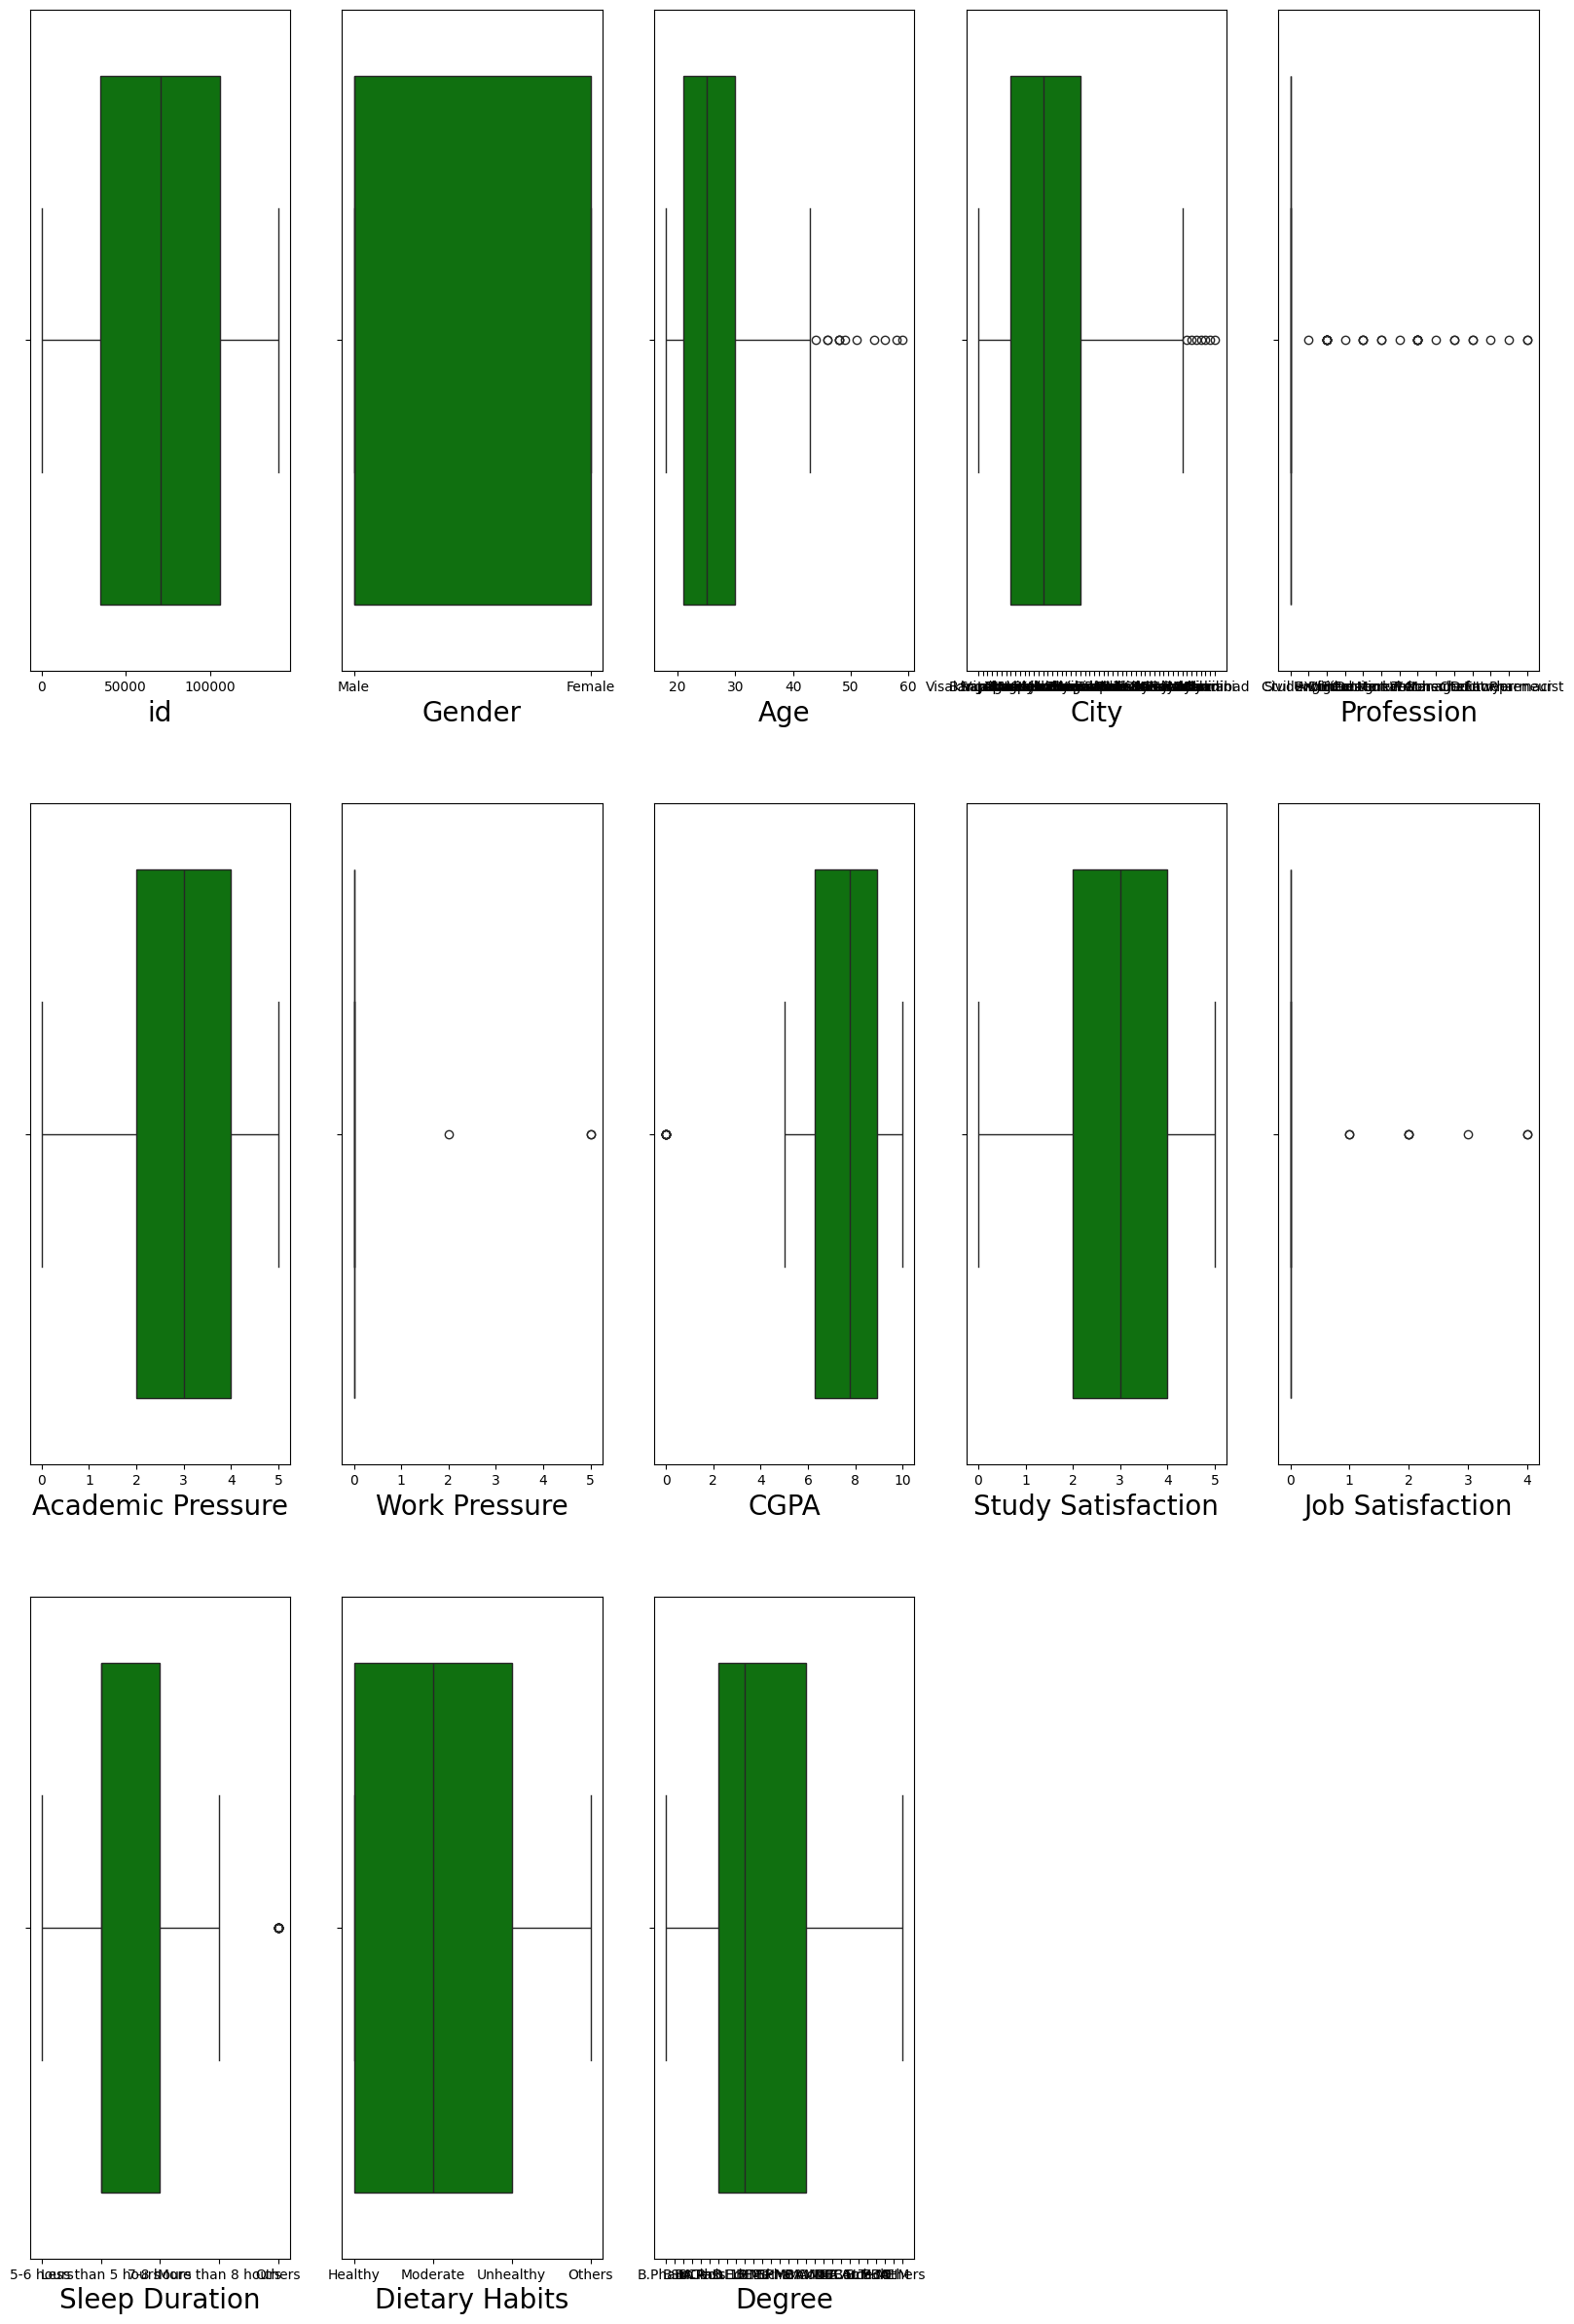

In [39]:
plt.figure(figsize=(20,30),facecolor='white')
plotnumber=1

for column in num:
    if plotnumber<=13:
        ax=plt.subplot(3,5,plotnumber)
        sns.boxplot(x = df[column],color='g')
        plt.xlabel(column,fontsize=20)
    plotnumber+=1
plt.show()

In [40]:
df = df.drop(['id'], axis = 1)

In [41]:
df.head()

,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,Male,33.0,Visakhapatnam,Student,5.0,0.0,8.97,2.0,0.0,5-6 hours,Healthy,B.Pharm,Yes,3.0,1.0,No,1
1,Female,24.0,Bangalore,Student,2.0,0.0,5.90,5.0,0.0,5-6 hours,Moderate,BSc,No,3.0,2.0,Yes,0
2,Male,31.0,Srinagar,Student,3.0,0.0,7.03,5.0,0.0,Less than 5 hours,Healthy,BA,No,9.0,1.0,Yes,0
3,Female,28.0,Varanasi,Student,3.0,0.0,5.59,2.0,0.0,7-8 hours,Moderate,BCA,Yes,4.0,5.0,Yes,1
4,Female,25.0,Jaipur,Student,4.0,0.0,8.13,3.0,0.0,5-6 hours,Moderate,M.Tech,Yes,1.0,1.0,No,0


In [42]:
from sklearn.preprocessing import OrdinalEncoder
oe = OrdinalEncoder()
def ordinal_encode(df, column):
    df[column] = oe.fit_transform(df[column])
    return df

oe_col = ['Sleep Duration','Dietary Habits','Degree','Profession'] 
df=ordinal_encode(df, oe_col)
df.head()

,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,Male,33.0,Visakhapatnam,11.0,5.0,0.0,8.97,2.0,0.0,0.0,0.0,3.0,Yes,3.0,1.0,No,1
1,Female,24.0,Bangalore,11.0,2.0,0.0,5.90,5.0,0.0,0.0,1.0,10.0,No,3.0,2.0,Yes,0
2,Male,31.0,Srinagar,11.0,3.0,0.0,7.03,5.0,0.0,2.0,0.0,5.0,No,9.0,1.0,Yes,0
3,Female,28.0,Varanasi,11.0,3.0,0.0,5.59,2.0,0.0,1.0,1.0,7.0,Yes,4.0,5.0,Yes,1
4,Female,25.0,Jaipur,11.0,4.0,0.0,8.13,3.0,0.0,0.0,1.0,17.0,Yes,1.0,1.0,No,0


In [43]:
# import pandas as pd
# from scipy import stats
# import numpy as np

# def remove_outliers(df, num_columns, cat_columns, cat_threshold=0.05, iqr_factor=1.7, z_thresh=1, min_data=0.9):
#     df_clean = df.copy()
#     original_size = len(df_clean)

#     for col in num_columns:
#         if pd.api.types.is_numeric_dtype(df_clean[col]): #Check if the column is numeric
#             Q1 = df_clean[col].quantile(0.25)
#             Q3 = df_clean[col].quantile(0.75)
#             IQR = Q3 - Q1

#             lower_bound = Q1 - iqr_factor * IQR
#             upper_bound = Q3 + iqr_factor * IQR

#             df_clean = df_clean[(df_clean[col] >= lower_bound) & (df_clean[col] <= upper_bound)]

#             if len(df_clean) > original_size * min_data:
#                 z_scores = np.abs(stats.zscore(df_clean[col]))
#                 df_clean = df_clean[z_scores < z_thresh]

#             if len(df_clean) < original_size * min_data:
#                 print(f"Stopping outlier removal for {col} to keep data balance.")
#                 break
#         else:
#             print(f"Column {col} is not numeric. Skipping outlier removal.")


#     for col in cat_columns:
#         value_counts = df_clean[col].value_counts(normalize=True)
#         rare_categories = value_counts[value_counts < cat_threshold].index
#         df_clean[col] = df_clean[col].replace(rare_categories, "Other")

#     print(f"Data Reduced: {original_size} → {len(df_clean)} rows ({len(df_clean)/original_size:.1%} data kept)")

#     return df_clean

# # Correctly categorize your columns:
# numerical_columns = ['Age', 'Academic Pressure', 'Work Pressure', 'CGPA', 'Study Satisfaction', 'Job Satisfaction', 'Work/Study Hours', 'Financial Stress']  # Corrected
# categorical_columns = ['Gender', 'City', 'Profession', 'Sleep Duration', 'Dietary Habits', 'Degree', 'Have you ever had suicidal thoughts ?', 'Family History of Mental Illness']  # Corrected

# df_cleaned = remove_outliers(df, numerical_columns, categorical_columns, iqr_factor=1.7, z_thresh=1)
# df_cleaned.info()

In [44]:
# Numeric=['Gender', 'Age', 'City', 'Profession', 'Academic Pressure',
#        'Work Pressure', 'CGPA', 'Study Satisfaction', 'Job Satisfaction',
#        'Sleep Duration', 'Dietary Habits', 'Degree',
#        'Have you ever had suicidal thoughts ?', 'Work/Study Hours',
#        'Financial Stress', 'Family History of Mental Illness', 'Depression',]
# plt.figure(figsize=(20,30),facecolor='white')
# plotnumber=1

# for column in Numeric:
#     if plotnumber<=28:
#         ax=plt.subplot(7,4,plotnumber)
#         sns.boxplot(x = df[column],color='g')
#         plt.xlabel(column,fontsize=20)
#     plotnumber+=1
# plt.show()

In [45]:
# Using Label Encoder on target variable
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df["Family History of Mental Illness"] = le.fit_transform(df["Family History of Mental Illness"])
df["Have you ever had suicidal thoughts ?"] = le.fit_transform(df["Have you ever had suicidal thoughts ?"])
df["Gender"] = le.fit_transform(df["Gender"])
df.head()

,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,1,33.0,Visakhapatnam,11.0,5.0,0.0,8.97,2.0,0.0,0.0,0.0,3.0,1,3.0,1.0,0,1
1,0,24.0,Bangalore,11.0,2.0,0.0,5.90,5.0,0.0,0.0,1.0,10.0,0,3.0,2.0,1,0
2,1,31.0,Srinagar,11.0,3.0,0.0,7.03,5.0,0.0,2.0,0.0,5.0,0,9.0,1.0,1,0
3,0,28.0,Varanasi,11.0,3.0,0.0,5.59,2.0,0.0,1.0,1.0,7.0,1,4.0,5.0,1,1
4,0,25.0,Jaipur,11.0,4.0,0.0,8.13,3.0,0.0,0.0,1.0,17.0,1,1.0,1.0,0,0


In [46]:
df = df.drop(['City'],axis =1)

In [47]:
# df.head()

In [48]:
# df_cleaned.shape

In [49]:
# from sklearn.preprocessing import OrdinalEncoder
# oe = OrdinalEncoder()
# def ordinal_encode(df, column):
#     df_cleaned[column] = oe.fit_transform(df_cleaned[column])
#     return df

# oe_col = ['Gender', 'City', 'Profession', 'Sleep Duration', 'Dietary Habits', 'Degree', 'Have you ever had suicidal thoughts ?','Family History of Mental Illness',]
# df=ordinal_encode(df_cleaned, oe_col)
# df_cleaned.head()

In [50]:
# df_cleaned.isnull().sum()

In [51]:
# df_cleaned.skew()

In [52]:
# plt.figure(figsize=(20, 20), facecolor='white')
# Category = ['Gender', 'Age', 'City', 'Profession', 'Academic Pressure',
#        'Work Pressure', 'CGPA', 'Study Satisfaction', 'Job Satisfaction',
#        'Sleep Duration', 'Dietary Habits', 'Degree',
#        'Have you ever had suicidal thoughts ?', 'Work/Study Hours',
#        'Financial Stress', 'Family History of Mental Illness', 'Depression',]
# plotnumber = 1
# for i in Category:
#     if plotnumber <= 18:
#         ax = plt.subplot(4, 5, plotnumber)
#         sns.kdeplot(data=df_cleaned, x=i, palette="Set1")
#         ax.set_xlabel(i, fontsize=20)
#         plt.xticks(rotation=30)
#     plotnumber += 1
# plt.tight_layout()
# plt.show()

In [53]:
df.skew()

Gender                                    -0.230407
Age                                        0.132239
Profession                               -39.590917
Academic Pressure                         -0.135165
Work Pressure                            108.594361
CGPA                                      -0.113063
Study Satisfaction                         0.010423
Job Satisfaction                          74.105663
Sleep Duration                            -0.034226
Dietary Habits                             0.228878
Degree                                     0.360525
Have you ever had suicidal thoughts ?     -0.551059
Work/Study Hours                          -0.454769
Financial Stress                          -0.130139
Family History of Mental Illness           0.064192
Depression                                -0.347126
dtype: float64

In [54]:
X = df.drop(['Depression'], axis =1)
Y = df['Depression']

In [55]:
from sklearn.preprocessing import power_transform
df = power_transform(X)
df = pd.DataFrame(df, columns=X.columns)
df.skew()

Gender                                   -0.230407
Age                                      -0.027637
Profession                               27.112673
Academic Pressure                        -0.148300
Work Pressure                            96.427865
CGPA                                     -0.068238
Study Satisfaction                       -0.112196
Job Satisfaction                         59.033889
Sleep Duration                           -0.162546
Dietary Habits                           -0.064003
Degree                                   -0.164573
Have you ever had suicidal thoughts ?    -0.551059
Work/Study Hours                         -0.368000
Financial Stress                         -0.162502
Family History of Mental Illness          0.064192
dtype: float64

In [56]:
df.head()

,Gender,Age,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness
0,0.891416,1.410118,0.009635,1.340470,-0.01037,0.892542,-0.657713,-0.016935,-1.476187,-1.330905,-1.104711,0.761745,-1.138585,-1.506090,-0.968421
1,-1.121811,-0.323897,0.009635,-0.823096,-0.01037,-1.190507,1.447639,-0.016935,-1.476187,-0.185805,0.020855,-1.312775,-1.138585,-0.782970,1.032609
2,0.891416,1.050303,0.009635,-0.096894,-0.01037,-0.438860,1.447639,-0.016935,0.494198,-1.330905,-0.731557,-1.312775,0.482289,-1.506090,1.032609
3,-1.121811,0.485197,0.009635,-0.096894,-0.01037,-1.393254,-0.657713,-0.016935,-0.429695,-0.185805,-0.407576,0.761745,-0.882135,1.281071,1.032609
4,-1.121811,-0.114963,0.009635,0.623921,-0.01037,0.310159,0.092538,-0.016935,-1.476187,-0.185805,0.862751,0.761745,-1.625179,-1.506090,-0.968421


In [57]:
# df.info()
df = df.astype(int)
df.head()


,Gender,Age,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness
0,0,1,0,1,0,0,0,0,-1,-1,-1,0,-1,-1,0
1,-1,0,0,0,0,-1,1,0,-1,0,0,-1,-1,0,1
2,0,1,0,0,0,0,1,0,0,-1,0,-1,0,-1,1
3,-1,0,0,0,0,-1,0,0,0,0,0,0,0,1,1
4,-1,0,0,0,0,0,0,0,-1,0,0,0,-1,-1,0


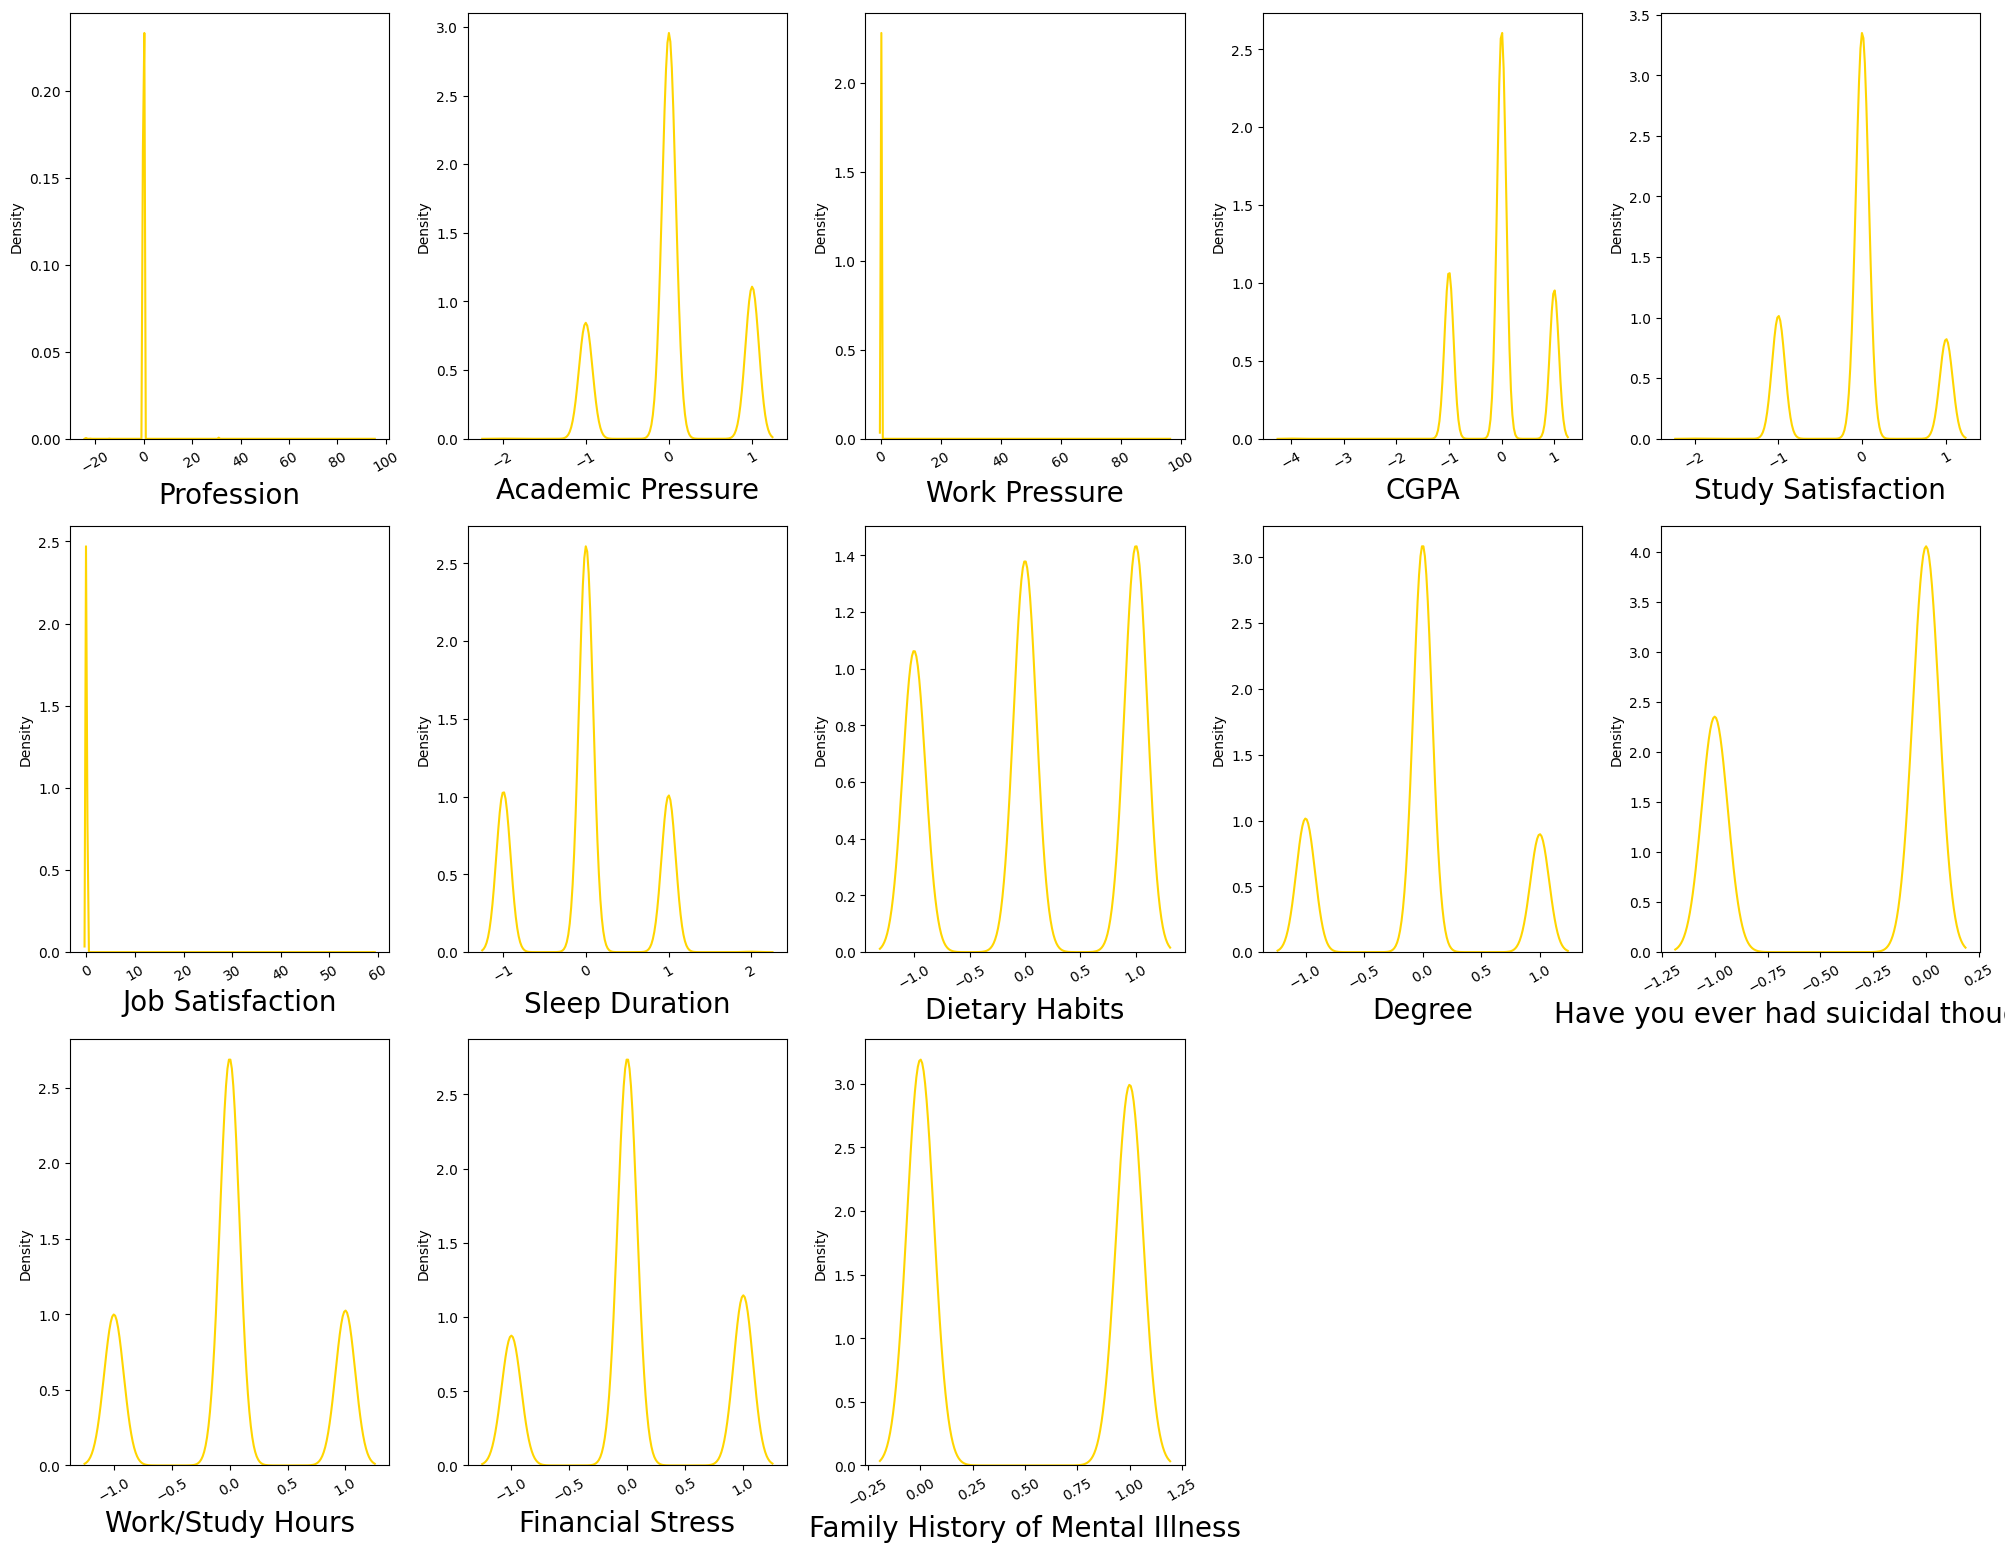

In [58]:
plt.figure(figsize=(20, 20), facecolor='white')
Category = ['Profession','Academic Pressure','Work Pressure','CGPA','Study Satisfaction','Job Satisfaction','Sleep Duration','Dietary Habits','Degree','Have you ever had suicidal thoughts ?','Work/Study Hours','Financial Stress','Family History of Mental Illness']
plotnumber = 1
for i in Category:
    if plotnumber <= 21:
        ax = plt.subplot(4, 5, plotnumber)
        sns.kdeplot(data=df, x=i, palette="Set1")
        ax.set_xlabel(i, fontsize=20)
        plt.xticks(rotation=30)
    plotnumber += 1
plt.tight_layout()
plt.show()

In [59]:
# plt.figure(figsize=(20, 20), facecolor='white')
# Category = ['Gender', 'Age', 'City', 'Profession', 'Academic Pressure',
#        'Work Pressure', 'CGPA', 'Study Satisfaction', 'Job Satisfaction',
#        'Sleep Duration', 'Dietary Habits', 'Degree',
#        'Have you ever had suicidal thoughts ?', 'Work/Study Hours',
#        'Financial Stress', 'Family History of Mental Illness', 'Depression',]
# plotnumber = 1
# for i in Category:
#     if plotnumber <= 18:
#         ax = plt.subplot(4, 5, plotnumber)
#         sns.kdeplot(data=df_cleaned, x=i, palette="Set1")
#         ax.set_xlabel(i, fontsize=20)
#         plt.xticks(rotation=30)
#     plotnumber += 1
# plt.tight_layout()
# plt.show()

In [60]:
# nan_count = df.isna().sum()
# print(nan_count)

In [61]:
# df.head

In [62]:
# df.corr()

In [63]:
# upper_triangle = np.triu(df.corr())
# plt.figure(figsize=(25,15))
# sns.heatmap(df.corr(), vmin=-1, vmax=1, annot=True, square=True, fmt='0.3f',
#             annot_kws={'size':10}, cmap="gist_stern", mask=upper_triangle)
# plt.xticks(fontsize=12)
# plt.yticks(fontsize=12)
# plt.show()

In [64]:
# !pip install imbalanced-learn


In [65]:
# from sklearn.impute import KNNImputer

# imputer = KNNImputer(n_neighbors=5)
# X_imputed = imputer.fit_transform(X)


In [66]:
# from imblearn.over_sampling import SMOTE
# # Oversampleing using SMOTE Techniques
# oversample = SMOTE()
# X, Y = oversample.fit_resample(X, Y)

In [67]:
# Y.value_counts()

In [68]:
# from sklearn.preprocessing import StandardScaler
# scaler= StandardScaler()
# X_scale = scaler.fit_transform(X)

In [69]:
# from sklearn.decomposition import PCA
# pca = PCA()
# #plot the graph to find the principal components
# x_pca = pca.fit_transform(X_scale)
# plt.figure(figsize=(10,10))
# plt.plot(np.cumsum(pca.explained_variance_ratio_), 'ro-')
# plt.xlabel('Number of Components')
# plt.ylabel('Variance %')
# plt.title('Explained variance Ratio')
# plt.grid()

In [70]:
# pca_new = PCA(n_components=17)
# x_new = pca_new.fit_transform(X_scale)

In [71]:
# principle_x=pd.DataFrame(x_new,columns=np.arange(17))

In [72]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix,classification_report,f1_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import BaggingClassifier

In [73]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, random_state=42, test_size=.33)
print('Training feature matrix size:',X_train.shape)
print('Training target vector size:',Y_train.shape)
print('Test feature matrix size:',X_test.shape)
print('Test target vector size:',Y_test.shape)

Training feature matrix size: (18693, 15)
Training target vector size: (18693,)
Test feature matrix size: (9208, 15)
Test target vector size: (9208,)


In [74]:
# X_train, X_test, Y_train, Y_test = train_test_split(principle_x, Y, random_state=242, test_size=.33)
# log_reg=LogisticRegression()
# log_reg.fit(X_train,Y_train)
# y_pred=log_reg.predict(X_test)
# print('\033[1m'+'Logistics Regression Evaluation'+'\033[0m')
# print('\n')
# print('\033[1m'+'Accuracy Score of Logistics Regression :'+'\033[0m', accuracy_score(Y_test, y_pred))
# print('\n')
# print('\033[1m'+'Confusion matrix of Logistics Regression :'+'\033[0m \n',confusion_matrix(Y_test, y_pred))
# print('\n')
# print('\033[1m'+'classification Report of Logistics Regression'+'\033[0m \n',classification_report(Y_test, y_pred))

In [75]:
# from sklearn import neighbors
# from math import sqrt
# from sklearn.metrics import mean_squared_error
# rmse_val = [] #to store rmse values for different k
# for K in range(30):
#     K = K+1
#     model = neighbors.KNeighborsClassifier(n_neighbors = K)

#     model.fit(X_train,Y_train)  #fit the model
#     y_pred=model.predict(X_test) #make prediction on test set
#     error = sqrt(mean_squared_error(Y_test,y_pred)) #calculate rmse
#     rmse_val.append(error) #store rmse values
#     print('RMSE value for k= ' , K , 'is:', error)

In [76]:
# #plotting the rmse values against k values -
# plt.figure(figsize = (8,6))
# plt.plot(range(30), rmse_val, color='blue', linestyle='dashed', marker='o', markerfacecolor='green', markersize=10)

In [77]:
model=[
        SVC(),
        GaussianNB(),
        DecisionTreeClassifier(),
        KNeighborsClassifier(n_neighbors = 2),
        RandomForestClassifier(),
        AdaBoostClassifier(),
        GradientBoostingClassifier(),
        BaggingClassifier()]

for m in model:
    m.fit(X_train,Y_train)
    y_pred=m.predict(X_test)
    print('\033[1m'+'Classification ML Algorithm Evaluation Matrix',m,'is' +'\033[0m')
    print('\n')
    print('\033[1m'+'Accuracy Score :'+'\033[0m\n', accuracy_score(Y_test, y_pred))
    print('\n')
    print('\033[1m'+'Confusion matrix :'+'\033[0m \n',confusion_matrix(Y_test, y_pred))
    print('\n')
    print('\033[1m'+'Classification Report :'+'\033[0m \n',classification_report(Y_test, y_pred))
    print('\n')
    print('============================================================================================================')

Classification ML Algorithm Evaluation Matrix SVC() is


Accuracy Score :
 0.8427454387489139


Confusion matrix : 
 [[3006  830]
 [ 618 4754]]


Classification Report : 
               precision    recall  f1-score   support

           0       0.83      0.78      0.81      3836
           1       0.85      0.88      0.87      5372

    accuracy                           0.84      9208
   macro avg       0.84      0.83      0.84      9208
weighted avg       0.84      0.84      0.84      9208



Classification ML Algorithm Evaluation Matrix GaussianNB() is


Accuracy Score :
 0.6545395308427454


Confusion matrix : 
 [[ 670 3166]
 [  15 5357]]


Classification Report : 
               precision    recall  f1-score   support

           0       0.98      0.17      0.30      3836
           1       0.63      1.00      0.77      5372

    accuracy                           0.65      9208
   macro avg       0.80      0.59      0.53      9208
weighted avg       0.77      0.65      0.57     

In [81]:
import pickle

# Save model
with open('depression_model.pkl', 'wb') as file:
    pickle.dump(model, file)
